In [1]:
import sys
print(sys.executable)

C:\Users\hankeun2\Desktop\brian_test\pram_env\Scripts\python.exe


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn import preprocessing as preprocessing
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image
from tqdm import tqdm, trange
from tensorboardX import SummaryWriter
from concurrent.futures import ThreadPoolExecutor
import time

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.figure import figaspect

import scipy.ndimage as ndimage
from scipy.optimize import curve_fit
from scipy.stats import multivariate_normal
import scipy.stats as stats
from scipy.ndimage import gaussian_filter, zoom
from absl import app, flags
from IPython import get_ipython
from IPython.display import clear_output
from skimage import io, morphology, filters, util

import gc 
from absl import app, flags
import datetime
import os
import sys
import cv2
from IPython.display import clear_output
from IPython import get_ipython
import random
import pandas as pd
import torch.multiprocessing as mp

if __name__ == '__main__':
    mp.set_start_method('spawn', force=True) # Add this line

# LOCA_PRAM — Downsampled variant

Identical to `LOCA_PRAM_main.ipynb` except for the `DOWNSCALE_FACTOR` config cell below, which downsamples the background image and shrinks the synthetic Gaussians (sigma + margin + window size) by the same factor. Set `DOWNSCALE_FACTOR = 1` to reproduce the original notebook.


In [2]:
# =====================================================================
# DOWNSCALE + PSF + MARKER CONFIG
# =====================================================================
DOWNSCALE_FACTOR = 2

BASE_WINDOW_SIZE = (256, 256)
window_size = (BASE_WINDOW_SIZE[0] // DOWNSCALE_FACTOR,
               BASE_WINDOW_SIZE[1] // DOWNSCALE_FACTOR)

# PSF sigmas: direct measurements from new PSF analysis, divided by DOWNSCALE_FACTOR.
BASE_SIGMA_X_LOC,   BASE_SIGMA_X_SCALE = 9.79, 1.32
BASE_SIGMA_Y_LOC,   BASE_SIGMA_Y_SCALE = 7.88, 1.38
BASE_SIGMA_MIN     = 2.5
BASE_MARGIN        = 12

SIGMA_X_LOC   = BASE_SIGMA_X_LOC   / DOWNSCALE_FACTOR
SIGMA_X_SCALE = BASE_SIGMA_X_SCALE / DOWNSCALE_FACTOR
SIGMA_Y_LOC   = BASE_SIGMA_Y_LOC   / DOWNSCALE_FACTOR
SIGMA_Y_SCALE = BASE_SIGMA_Y_SCALE / DOWNSCALE_FACTOR
SIGMA_MIN     = BASE_SIGMA_MIN     / DOWNSCALE_FACTOR
MARGIN        = max(1, int(round(BASE_MARGIN / DOWNSCALE_FACTOR)))

# ---- PSF amplitude distribution ----
# Empirical PSF amplitudes (n=145 after outlier removal) modeled as a Beta
# bounded to [AMP_FLOOR, AMP_CEIL]: smooth, right-skewed, and (unlike the old
# Gaussian) strictly cannot emit sub-noise amplitudes. Source: amplitude_samples.npy
# from the PSF-analysis cell.
# NOTE: amplitude is an INTENSITY, not a length, so it is NOT divided by
# DOWNSCALE_FACTOR — average-pool downsampling preserves the peak of a
# well-sampled Gaussian (same as the old code, which used the native 31.22).
import numpy as np
from scipy import stats as _stats
_amp = np.load('amplitude_samples.npy')
AMP_FLOOR  = 12.0
AMP_CEIL   = float(_amp.max() + 0.03 * (_amp.max() - _amp.min()))
AMP_BETA_A, AMP_BETA_B, _, _ = _stats.beta.fit(
    _amp, floc=AMP_FLOOR, fscale=AMP_CEIL - AMP_FLOOR)

def sample_amplitude(size=None):
    """Particle amplitude(s) drawn from the fitted Beta (native intensity units)."""
    return _stats.beta.rvs(AMP_BETA_A, AMP_BETA_B, loc=AMP_FLOOR,
                           scale=AMP_CEIL - AMP_FLOOR, size=size)

# Marker / banned-region config.
MARKER_THRESHOLD = 15
BUFFER_SIGMA_MULT = 5.0
BUFFER_PX = int(round(BUFFER_SIGMA_MULT * max(SIGMA_X_LOC, SIGMA_Y_LOC)))


def compute_forbidden_mask(tile, buffer_px=None, threshold=None):
    if buffer_px is None:
        buffer_px = BUFFER_PX
    if threshold is None:
        threshold = MARKER_THRESHOLD
    marker = tile <= threshold
    if buffer_px <= 0 or not marker.any():
        return marker
    from scipy.ndimage import distance_transform_edt
    dist = distance_transform_edt(~marker)
    return dist <= buffer_px


def downsample_image(img, factor=None):
    if factor is None:
        factor = DOWNSCALE_FACTOR
    if factor == 1:
        return img
    import cv2
    h, w = img.shape[:2]
    return cv2.resize(img, (w // factor, h // factor), interpolation=cv2.INTER_AREA)


GAUSSIAN_BLUR_SIGMA = 0.0

def smooth_image(img, sigma=None):
    if sigma is None:
        sigma = GAUSSIAN_BLUR_SIGMA
    if sigma <= 0:
        return img
    from scipy.ndimage import gaussian_filter
    return gaussian_filter(img, sigma=sigma)


print(f"DOWNSCALE_FACTOR = {DOWNSCALE_FACTOR}")
print(f"window_size      = {window_size}")
print(f"sigma_x ~ N({SIGMA_X_LOC:.2f}, {SIGMA_X_SCALE:.2f})")
print(f"sigma_y ~ N({SIGMA_Y_LOC:.2f}, {SIGMA_Y_SCALE:.2f})")
print(f"amplitude ~ Beta(a={AMP_BETA_A:.2f}, b={AMP_BETA_B:.2f}) on [{AMP_FLOOR:.1f}, {AMP_CEIL:.1f}]")
print(f"placement margin = {MARGIN}, marker buffer = {BUFFER_PX} px ({BUFFER_SIGMA_MULT:.1f}*sigma)")
print(f"gaussian blur    = {GAUSSIAN_BLUR_SIGMA} px")

DOWNSCALE_FACTOR = 2
window_size      = (128, 128)
sigma_x ~ N(4.89, 0.66)
sigma_y ~ N(3.94, 0.69)
amplitude ~ Beta(a=1.92, b=2.98) on [12.0, 58.3]
placement margin = 6, marker buffer = 24 px (5.0*sigma)
gaussian blur    = 0.0 px


## Prepare Background Tiles

In [3]:
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

def standardize_image(image):
    """
    Standardize the pixel values of a 16-bit image so that the resulting image
    has a mean of 0 and a standard deviation of 1.

    Parameters:
    - image: A NumPy array representing the 16-bit input image.

    Returns:
    - A NumPy array of the standardized image.
    """
    image = image.astype(np.float32) / 255.
    mean = np.mean(image)
    std = np.std(image)
    standardized_image = (image - mean) / std
    print(f"mean: {mean}, std: {std}")
    return standardized_image

def shadow_remove(img):     
    """
    (Explanation needed)

    Parameters:
    - image: A NumPy array representing the 16-bit input image.

    Returns:
    - A NumPy array of the shadow removed image.
    """   
    dilated_img = morphology.dilation(img, morphology.square(11))
    bg_img = filters.median(dilated_img, morphology.disk(31))
    shadowremov = img - bg_img
    return shadowremov

def save_image(image):
    print(image.dtype)
    # Before saving, rescale and convert the processed image back to 16-bit
    final_img_16bit = rescale_to_16bit(image)
    cv2.imwrite('background_subtracted.png', final_img_16bit)

def rescale_to_16bit(image_float, target_range=(0, 65535)):
    """
    Rescales a floating-point image to the specified 16-bit range.

    Parameters:
    - image_float: A NumPy array of the image in floating-point format.
    - target_range: A tuple specifying the desired output range (min, max).

    Returns:
    - A NumPy array of the image rescaled to the 16-bit range.
    """
    min_val = np.min(image_float)
    max_val = np.max(image_float)
    scale = (target_range[1] - target_range[0]) / (max_val - min_val)
    image_16bit = (image_float - min_val) * scale + target_range[0]
    return image_16bit.astype(np.uint16)

def visualize_image(images, labels, backgrounds, image_index=0, figsize=(2000, 800)):
    """
    Visualize the images. 
    - image:            Number of training images generated. 
                        (num_imgs, 1, img_width, img_height)
    - background:       Previously generated "bg_tiles" is used. 
                        (num_imgs, 1, img_width, img_height)
    - labels:           One-hot representation of the center of the PSFs. 
                        (num_imgs, 1, img_width, img_height)
    - labels_density:   When "labels" are the one-hot representation, "label_density" has pixel value of 100 followed by smoothing with gaussian filter 
                        (num_imgs, 1, img_width, img_height)
    - image_index:      For sanity check, a single image from the training set is displayed. 
                        (int)
    - figsize:          Size of the figure. 
                        ex) (1000, 1000)
                        
    Returns:
    - None
    """   

    if labels.ndim == 3:
        labels = labels.unsqueeze(0)
        backgrounds = backgrounds.unsqueeze(0)
    if images.ndim == 3:
        images = images.unsqueeze(0)
    
    print(f"image index: {image_index}")
    num_imgs, img_channel, img_size_x, img_size_y = images.shape
    px = 1/plt.rcParams['figure.dpi'] 
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(figsize[0]*px, figsize[1]*px))

    for i, ax in enumerate(axes.flatten()):
        D = np.squeeze(images[image_index, ...] )
        if not i % 4:
            GT = np.squeeze(labels[image_index, 2, ...] > 0)
            BG = np.squeeze(backgrounds[image_index, 0, ...])
            a = ax.imshow(D, origin='lower', cmap='gray')
            ax.set_title('Input Image')
        if i%4 == 1:
            a = ax.imshow(BG, origin='lower', cmap='gray')
            ax.set_title('Input Background')
        if i%4 == 2:
            a = ax.imshow(GT, origin='lower', cmap='gray')
            ax.set_title('Ground Truth Center')
            
        fig.colorbar(a, ax=ax, fraction=0.046)
        ax.set_xlim([0, img_size_x])
        ax.set_ylim([img_size_y, 0])

    plt.tight_layout()
    plt.show()
    
def prepare_background_tiles(bg_image_path, window_size):
    """
    Load a synthetic background image and tile it.
    
    Parameters:
    - bg_image_path: Path to the synthetic background image
    - window_size: Tuple (height, width) for each tile
    
    Returns:
    - bg_tiles: NumPy array of shape (num_tiles, height, width)
    """
    # Load image
    bg_image = np.asarray(Image.open(bg_image_path).convert('L')).astype(np.float32)
    if DOWNSCALE_FACTOR != 1:
        bg_image = downsample_image(bg_image)
        print(f"Downsampled background by {DOWNSCALE_FACTOR}x: {bg_image.shape}")
    print(f"Loaded background: {bg_image.shape}, range: [{bg_image.min():.1f}, {bg_image.max():.1f}]")
    
    # Normalize to 0-1
    bg_image = (bg_image - bg_image.min()) / (bg_image.max() - bg_image.min())
    
    bg_height, bg_width = bg_image.shape
    bg_tiles = []
    
    # Tile the image
    for i in range(int(bg_height / window_size[0])):
        for j in range(int(bg_width / window_size[1])):
            bg_tile = bg_image[i*window_size[0] : i*window_size[0] + window_size[0], 
                               j*window_size[1] : j*window_size[1] + window_size[1]]
            bg_tiles.append(bg_tile)
    
    bg_tiles = np.asarray(bg_tiles)
    print(f"Generated {len(bg_tiles)} tiles of size {window_size}")
    
    # Visualization
    index = 0
    fig, subplots = plt.subplots(1, 2, figsize=(16, 6))
    subplots[0].set_title("Synthetic Background")
    subplot_0 = subplots[0].imshow(bg_image, cmap='gray')
    rect = patches.Rectangle((window_size[1] * (index % int(bg_width / window_size[1])), 
                               window_size[0] * (index // int(bg_width / window_size[1]))), 
                              window_size[1], window_size[0], linewidth=2, linestyle='--', 
                              edgecolor='r', facecolor='none')
    subplots[0].add_patch(rect)
    fig.colorbar(subplot_0, ax=subplots[0], fraction=0.03)
    subplot_1 = subplots[1].imshow(bg_tiles[index].squeeze(), cmap='gray')
    subplots[1].set_title(f"Tile #{index}")
    fig.colorbar(subplot_1, ax=subplots[1], fraction=0.05)
    plt.tight_layout()
    plt.show()
    
    return bg_tiles

if __name__ == '__main__':
    # NOTE: original single-image loader disabled; the real loader is
    # in the next code cell (multi-FOV from the demo_0001 folder).
    pass


## Authentic Image for Testing
### Sanity Check

In [4]:
# =====================================================================
# Multi-FOV background loader
# ---------------------------------------------------------------------
# Walks the BG_FOLDER, splits FOVs into train / eval, takes the RED
# channel of each JPG, sub-tiles each FOV at window_size, drops tiles
# that are essentially 100% marker (no usable signal). Produces two
# pools: bg_tiles_train and bg_tiles_eval. bg_tiles is aliased to the
# train pool for backward compatibility with the visualization cells.
# =====================================================================
import glob
import os

BG_FOLDER = 'demo_0001'
TRAIN_FOV_COUNT = 100
SPLIT_SEED = 42
# Min fraction of pixels that are placeable AFTER marker dilation + edge margin.
# Direct gate on what generate_simulation_image can actually use; replaces the
# raw marker_frac threshold which underestimated the impact of the sigma buffer
# at small tile sizes (a 65% marker tile can have 0% placeable area at 128x128).
MIN_PLACEABLE_FRAC = 0.05


def load_fov_red(path):
    """Open a JPG FOV and return the red channel as float32 (0-255 range)."""
    arr = np.asarray(Image.open(path))
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    arr = arr.astype(np.float32)
    if DOWNSCALE_FACTOR != 1:
        arr = downsample_image(arr)
    return arr


def _placeable_frac(tile):
    """Fraction of pixels that pass marker dilation + edge margin — i.e. that
    generate_simulation_image could actually place a particle on."""
    forbidden = compute_forbidden_mask(tile)
    if MARGIN > 0:
        forbidden[:MARGIN, :] = True
        forbidden[-MARGIN:, :] = True
        forbidden[:, :MARGIN] = True
        forbidden[:, -MARGIN:] = True
    return float((~forbidden).mean())


def tile_fovs(fov_paths, window_size, label=""):
    tiles = []
    n_dropped = 0
    for p in fov_paths:
        img = load_fov_red(p)
        h, w = img.shape
        for i in range(h // window_size[0]):
            for j in range(w // window_size[1]):
                tile = img[i*window_size[0]:(i+1)*window_size[0],
                           j*window_size[1]:(j+1)*window_size[1]]
                if _placeable_frac(tile) < MIN_PLACEABLE_FRAC:
                    n_dropped += 1
                    continue
                # Blur applied AFTER the placeable filter (which needs raw
                # values for the marker threshold) but BEFORE storing — so
                # bg_tiles holds smoothed tiles and bg-head input/target stay
                # consistent. No-op if sigma=0.
                tile = smooth_image(tile)
                tiles.append(tile)
    arr = np.asarray(tiles)
    print(f"  {label}: {len(fov_paths)} FOVs -> {len(arr)} tiles "
          f"(dropped {n_dropped} with placeable_frac < {MIN_PLACEABLE_FRAC:.0%})")
    return arr


all_fovs = sorted(glob.glob(os.path.join(BG_FOLDER, '*.jpg')))
assert len(all_fovs) > TRAIN_FOV_COUNT, \
    f"need > {TRAIN_FOV_COUNT} FOVs in {BG_FOLDER}, found {len(all_fovs)}"

rng = np.random.RandomState(SPLIT_SEED)
perm = rng.permutation(len(all_fovs))
train_fovs = [all_fovs[i] for i in perm[:TRAIN_FOV_COUNT]]
eval_fovs  = [all_fovs[i] for i in perm[TRAIN_FOV_COUNT:]]
print(f"Loaded {len(all_fovs)} FOVs from {BG_FOLDER}")
print(f"  train: {len(train_fovs)} FOVs")
print(f"  eval : {len(eval_fovs)} FOVs (held out)")

bg_tiles_train = tile_fovs(train_fovs, window_size, label="train")
bg_tiles_eval  = tile_fovs(eval_fovs,  window_size, label="eval ")

# Alias for backward compatibility with later visualization cells.
bg_tiles = bg_tiles_train

print(f"Tile value range (train): "
      f"[{bg_tiles_train.min():.1f}, {bg_tiles_train.max():.1f}]")


Loaded 126 FOVs from demo_0001
  train: 100 FOVs
  eval : 26 FOVs (held out)
  train: 100 FOVs -> 16005 tiles (dropped 495 with placeable_frac < 5%)
  eval : 26 FOVs -> 4151 tiles (dropped 139 with placeable_frac < 5%)
Tile value range (train): [0.0, 255.0]


## Training Data Generation

In [5]:
def generate_simulation_image(img_size, bg_tiles, num_gaus_low=1, num_gaus_high=15, labels_channel=3):
    """
    Generates a simulated image with synthetic PSF particles on a real
    background tile (sampled at random from bg_tiles).
    Amplitude now drawn from the fitted Beta distribution (see config cell).
    """
    bg_idx = np.random.randint(0, len(bg_tiles))
    gauss_base = bg_tiles[bg_idx].copy()
    bg_clean   = bg_tiles[bg_idx]

    # ---- Forbidden mask: markers dilated by BUFFER_PX, plus edge margin ----
    forbidden = compute_forbidden_mask(bg_clean)
    if MARGIN > 0:
        forbidden[:MARGIN, :] = True
        forbidden[-MARGIN:, :] = True
        forbidden[:, :MARGIN] = True
        forbidden[:, -MARGIN:] = True

    placeable_ys, placeable_xs = np.where(~forbidden)
    active_frac = placeable_ys.size / forbidden.size

    x_vec = np.arange(img_size[1])
    y_vec = np.arange(img_size[0])

    labels = np.zeros((labels_channel, img_size[0], img_size[1]))

    # ---- Density-aware particle count (stochastic rounding) ----
    nominal_count = np.random.randint(num_gaus_low, num_gaus_high)
    scaled = nominal_count * active_frac
    n_floor = int(scaled)
    n_to_place = n_floor + (1 if np.random.random() < (scaled - n_floor) else 0)

    if placeable_ys.size == 0:
        n_to_place = 0

    for _ in range(n_to_place):
        # 1. Sample center from placeable pixels (+ sub-pixel jitter)
        k = np.random.randint(0, placeable_ys.size)
        iy_base = placeable_ys[k]
        ix_base = placeable_xs[k]
        x_c = ix_base + np.random.uniform(0, 1)
        y_c = iy_base + np.random.uniform(0, 1)

        # 2. Sample amplitude from the fitted Beta (bounded, right-skewed;
        #    defined in the config cell). Replaces the old Gaussian, which
        #    leaked sub-noise amplitudes. No <1.0 clamp needed — Beta ≥ AMP_FLOOR.
        amplitude = float(sample_amplitude())

        # 3. Sample sigma (PSF-measured + downscaled values)
        raw_sigma_x = np.random.normal(loc=SIGMA_X_LOC, scale=SIGMA_X_SCALE)
        raw_sigma_y = np.random.normal(loc=SIGMA_Y_LOC, scale=SIGMA_Y_SCALE)
        sigma_x = max(SIGMA_MIN, raw_sigma_x)
        sigma_y = max(SIGMA_MIN, raw_sigma_y)

        # 4. Render separable Gaussian
        g_x = np.exp(-((x_vec - x_c) ** 2) / (2 * sigma_x ** 2))
        g_y = np.exp(-((y_vec - y_c) ** 2) / (2 * sigma_y ** 2))
        particle = np.outer(g_y, g_x) * amplitude

        gauss_base -= particle

        # 5. Update labels (one-hot at the integer center)
        ix, iy = int(x_c), int(y_c)
        if 0 <= ix < img_size[1] and 0 <= iy < img_size[0]:
            labels[0, iy, ix] = x_c - ix
            labels[1, iy, ix] = y_c - iy
            labels[2, iy, ix] = 1.0

    gauss_base = np.clip(gauss_base, 0, 65535)
    return gauss_base, labels, bg_clean

In [6]:
tile = bg_tiles[0]
print(f"Tile mean: {tile.mean():.1f}")
print(f"Tile std:  {tile.std():.1f}")
print(f"Tile local std (32x32 patches):")
for y in range(0, 512, 128):
    for x in range(0, 512, 128):
        patch = tile[y:y+32, x:x+32]
        print(f"  ({y},{x}): std={patch.std():.2f}")
print(f"Particle amplitude: ~10")
print(f"Noise level: ~2.7")

Tile mean: 246.9
Tile std:  5.6
Tile local std (32x32 patches):
  (0,0): std=2.46
  (0,128): std=nan
  (0,256): std=nan
  (0,384): std=nan
  (128,0): std=nan
  (128,128): std=nan
  (128,256): std=nan
  (128,384): std=nan
  (256,0): std=nan
  (256,128): std=nan
  (256,256): std=nan
  (256,384): std=nan
  (384,0): std=nan
  (384,128): std=nan
  (384,256): std=nan
  (384,384): std=nan
Particle amplitude: ~10
Noise level: ~2.7


C:\Users\hankeun2\Desktop\brian_test\pram_env\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\hankeun2\Desktop\brian_test\pram_env\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\hankeun2\Desktop\brian_test\pram_env\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


### Asynchronous Dataset Loading

Visual comparison: Background vs Background+Particles


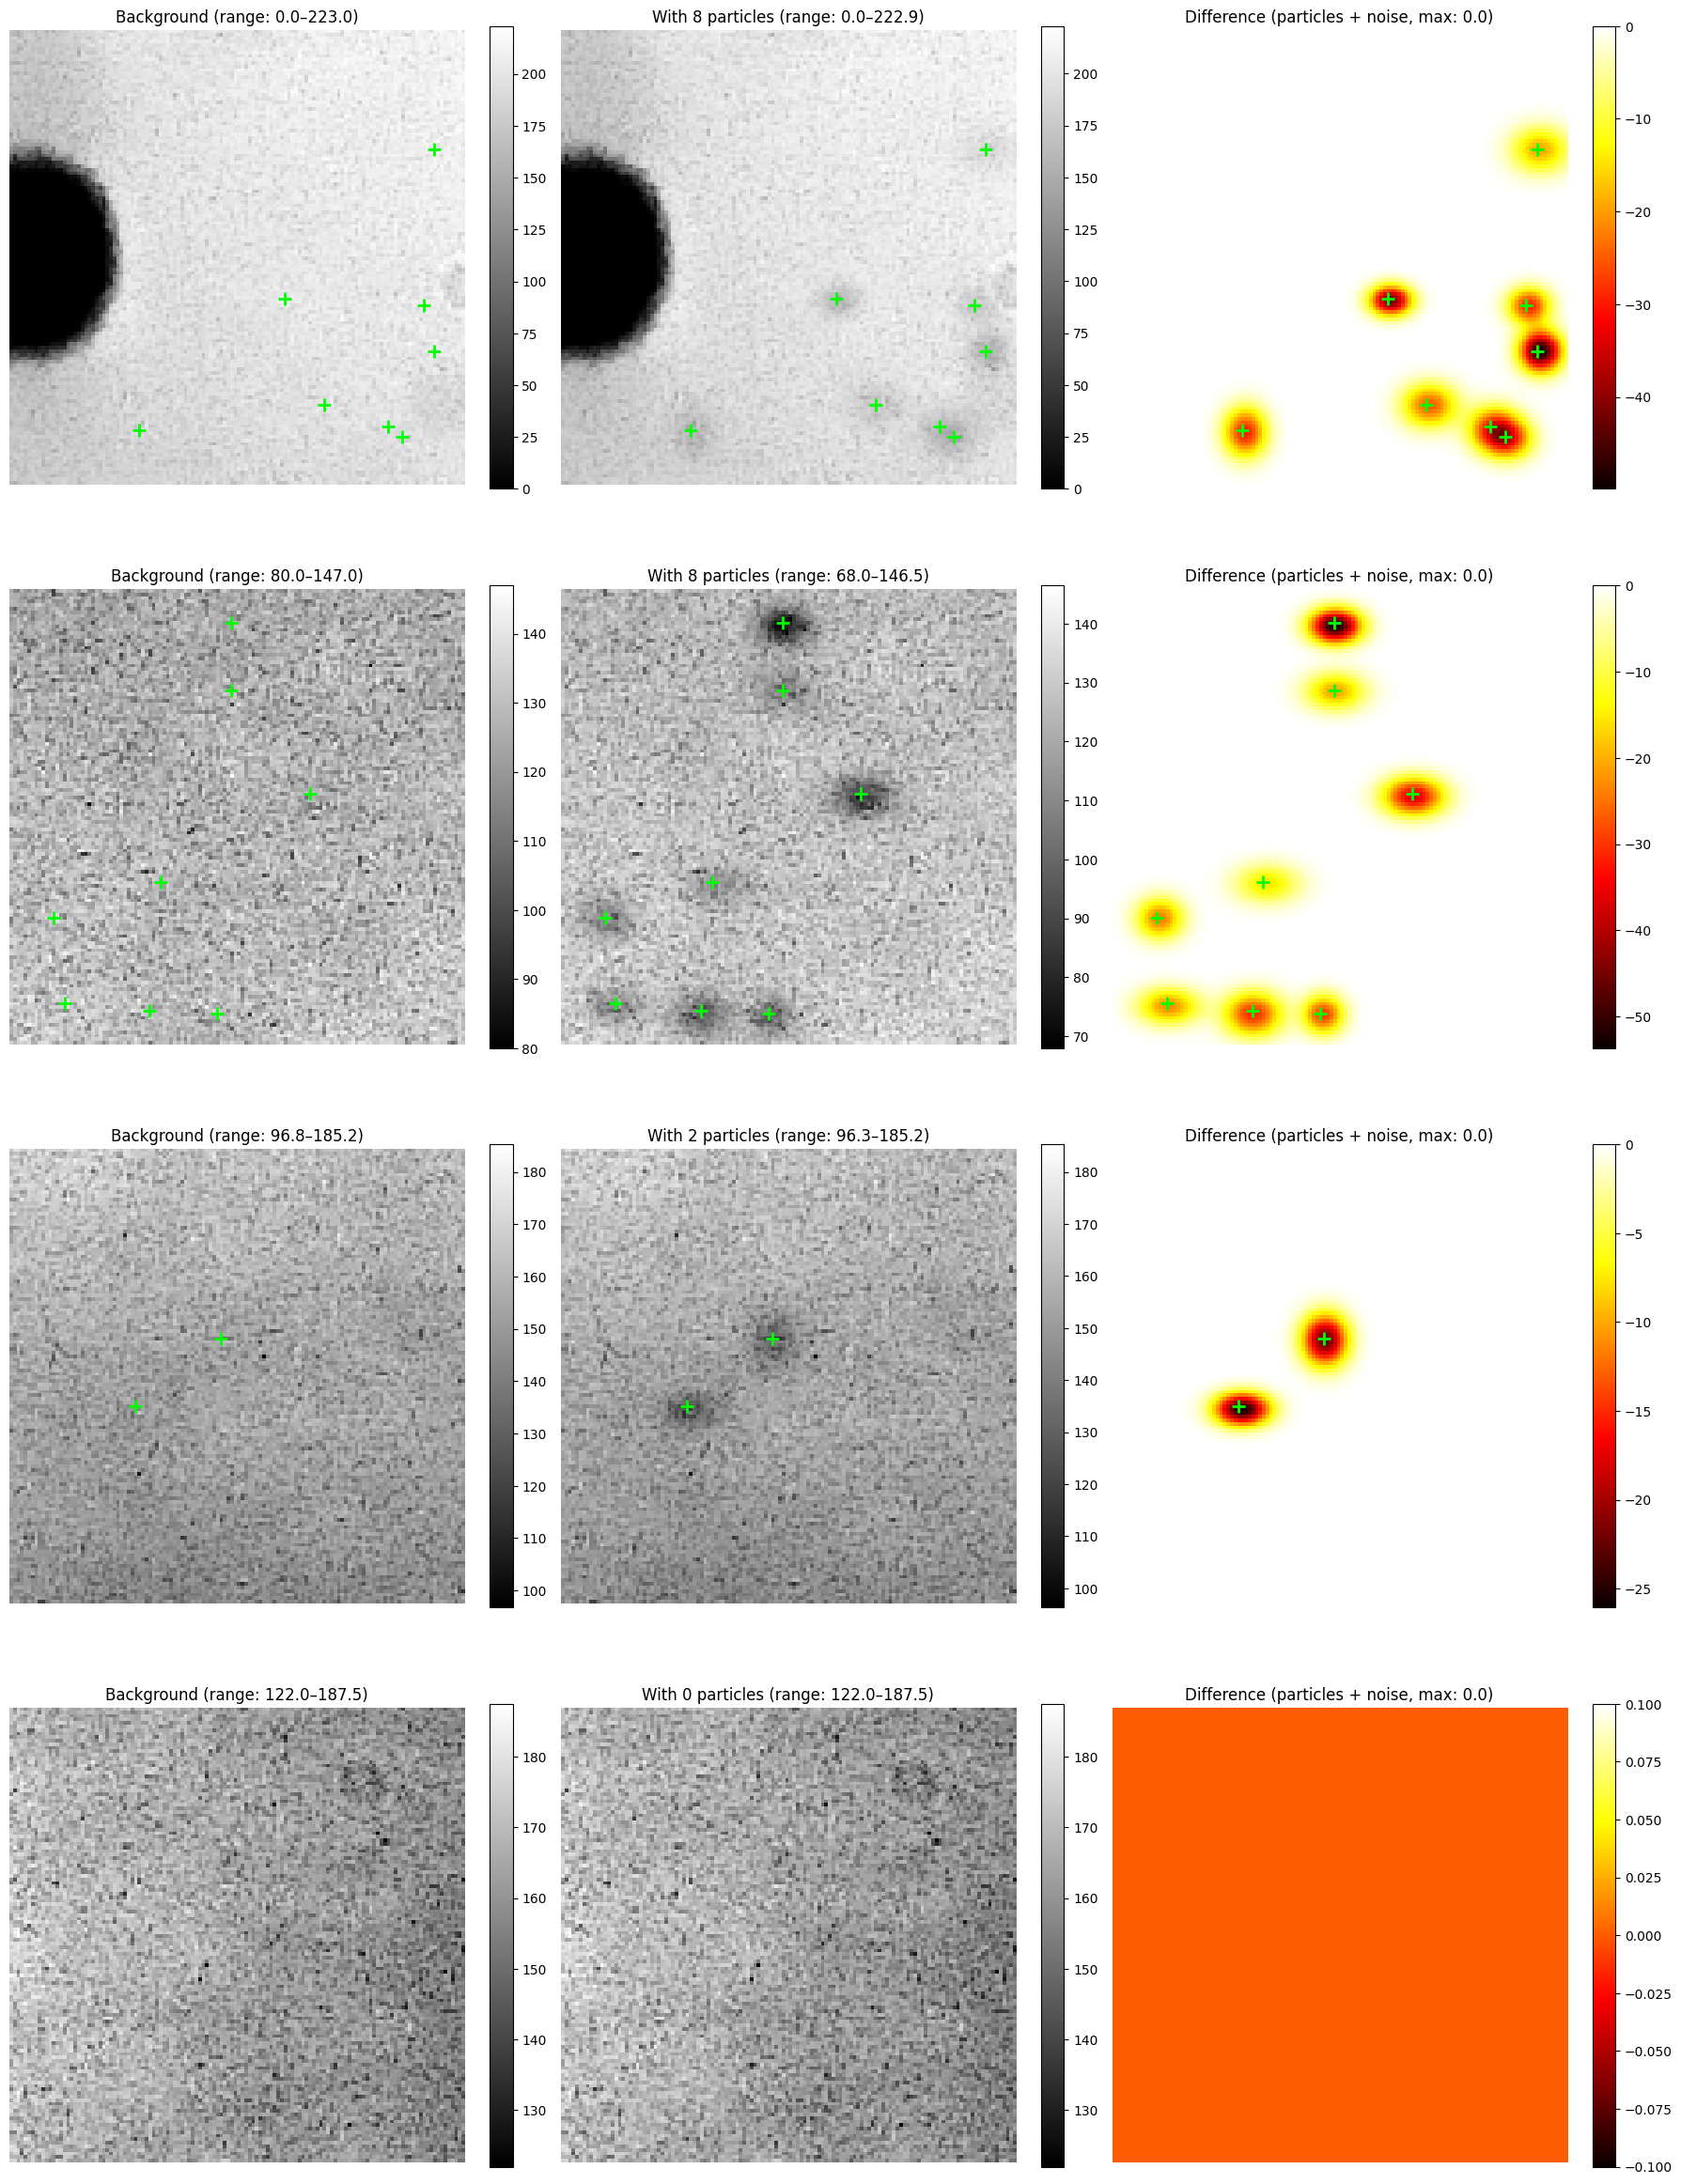

In [7]:
class GaussianDataset(Dataset):
    def __init__(self, num_batches, bg_tiles, img_size=(512, 512), transform=None):
        self.transform = transform
        self.num_batches = num_batches
        self.bg_tiles = bg_tiles
        self.img_size = img_size
        self.labels_channel = 3
        
        # --- DYNAMIC DENSITY CALCULATION ---
        # Goal: Keep particle-to-image coverage ratio consistent with the original version (20% coverage)
        
        # 1. Reference (Original Setup)
        # 50 particles (radius ~3px) in 84x84
        ref_coverage_ratio = 0.20 
        
        # 2. New Setup (Current Config)
        new_window_area = self.img_size[0] * self.img_size[1]
        
        
        # PSF area shrank ~16x (sigma 4x smaller); bumped 4x to 0-23 so we
        # actually get overlapping particles for the model to learn that case.
        self.num_gaus_low = 0
        self.num_gaus_high = 15
        
        # print(f"Density Calculation for {img_size}:")
        # print(f"  - Particle Dimensions: ~{int(new_sigma_x*4)}x{int(new_sigma_y*4)} pixels")
        # print(f"  - Max Particles set to: {self.num_gaus_high}")

    def __len__(self):
        return self.num_batches

    def __getitem__(self, idx):
        # We call the generate function we defined in the previous cell
        image, labels, bg_image = generate_simulation_image(
            img_size=self.img_size, 
            bg_tiles=self.bg_tiles, 
            num_gaus_low=self.num_gaus_low, 
            num_gaus_high=self.num_gaus_high,
            labels_channel=self.labels_channel
        )
        
        # Standardize / Normalize -- ignore marker pixels so one black
        # block doesn't dominate the mean/std and crush contrast.
        valid = bg_image > MARKER_THRESHOLD
        if valid.any():
            m = image[valid].mean()
            s = image[valid].std()
        else:
            m = image.mean()
            s = image.std()
        if s == 0:
            s = 1
        image = (image - m) / s
        
        # Normalize bg_image with the SAME (m, s) as input so the bg head
        # supervises in the same normalized space.
        bg_image = (bg_image - m) / s

        # Convert to Tensor
        image = torch.from_numpy(image).float().unsqueeze(0) # (1, H, W)
        labels = torch.from_numpy(labels).float()            # (3, H, W)
        bg_image = torch.from_numpy(bg_image).float().unsqueeze(0)
        
        # Apply transforms if they exist
        if self.transform:
            image = self.transform(image)
            
        return image, labels, bg_image

# Asynchronous data loading function for batches
def async_load_batch(data_loader):
    """Load batches asynchronously using a thread pool."""
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(load_batch, batch) for batch in data_loader]
        for future in futures:
            yield future.result()

def load_batch(batch):
    """Simulate batch loading (you can customize this to fit your process)."""
    time.sleep(0.1)  # Simulate a delay (remove or adjust depending on your loading time)
    return batch

# Sanity Check: Visualizing asynchronously generated data
def sanity_check(images):
    plt.figure(figsize=(8, 8))
    # Loop over generated data for visualization and checking
    for i in range(images.shape[0]):
        if i < 4 :
            plt.subplot(2, 2, i + 1)
            plt.imshow(images[i].squeeze(), cmap='gray')
            plt.colorbar()
            plt.title(f"Generated Image {i+1}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    # Generate a few images and show background vs background+particles side by side
    print("Visual comparison: Background vs Background+Particles")
    
    num_examples = 4
    fig, axes = plt.subplots(num_examples, 3, figsize=(18, 6 * num_examples))
    
    for i in range(num_examples):
        image, labels, bg_image = generate_simulation_image(
            img_size=window_size,
            bg_tiles=bg_tiles,
            num_gaus_low=0,
            num_gaus_high=15,
            labels_channel=3
        )
        
        diff = image - bg_image  # isolates particles + noise
        
        # A. Background only
        axes[i, 0].imshow(bg_image, cmap='gray')
        axes[i, 0].set_title(f'Background (range: {bg_image.min():.1f}–{bg_image.max():.1f})')
        fig.colorbar(axes[i, 0].images[0], ax=axes[i, 0], fraction=0.046)
        
        # B. Background + particles
        axes[i, 1].imshow(image, cmap='gray')
        num_particles = int(labels[2].sum())
        axes[i, 1].set_title(f'With {num_particles} particles (range: {image.min():.1f}–{image.max():.1f})')
        fig.colorbar(axes[i, 1].images[0], ax=axes[i, 1], fraction=0.046)
        
        # C. Difference (particles + noise only)
        im = axes[i, 2].imshow(diff, cmap='hot')
        axes[i, 2].set_title(f'Difference (particles + noise, max: {diff.max():.1f})')
        fig.colorbar(im, ax=axes[i, 2], fraction=0.046)
        
        # Mark true centers on all panels
        ys, xs = np.where(labels[2] > 0)
        for ax in axes[i]:
            ax.scatter(xs, ys, color='lime', marker='+', s=100, linewidths=2)
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

Heaviest usable tile: idx 3990, marker frac = 48.74%
Active frac (after marker dilation + edge margin): 9.33%


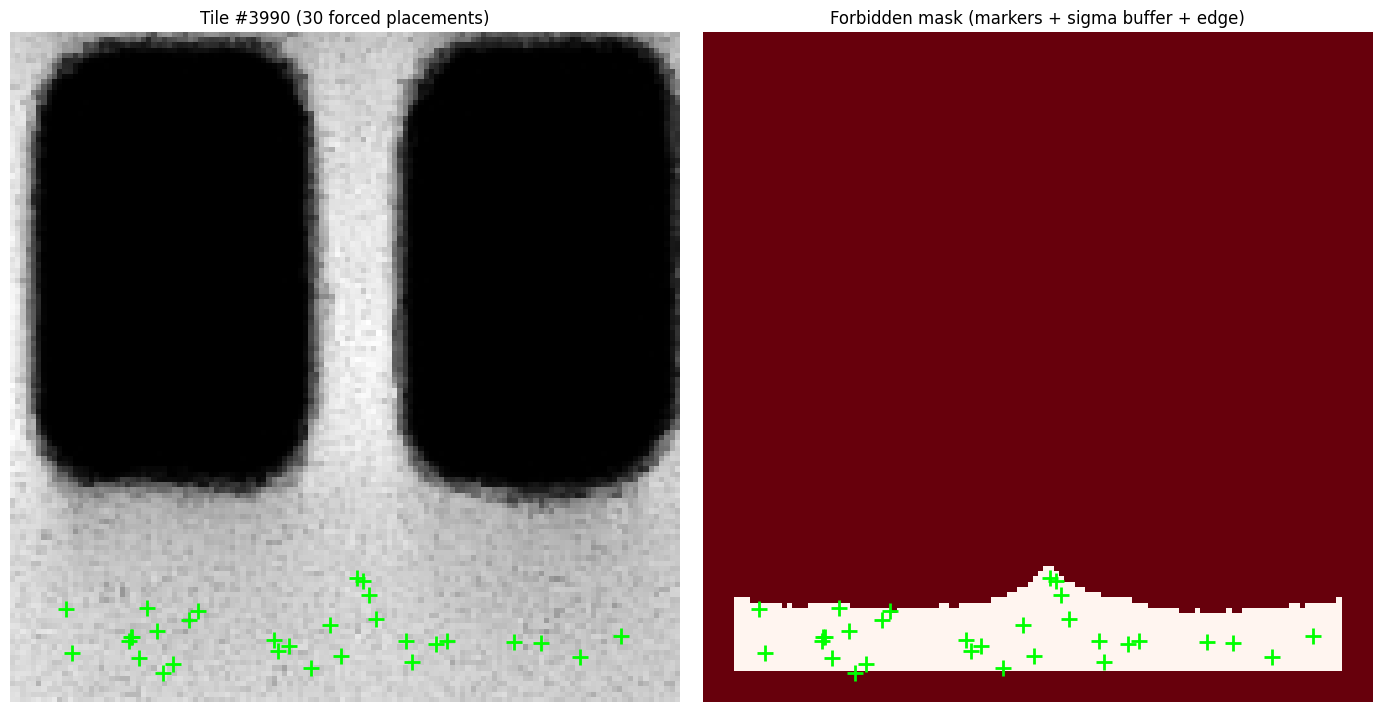

Sampled centers inside forbidden mask: 0 / 30 (should be 0)


In [8]:
# =====================================================================
# Marker-avoidance diagnostic
# ---------------------------------------------------------------------
# Picks the tile with the heaviest marker coverage, draws the forbidden
# mask (markers + sigma buffer), then places 30 particles *unconditionally*
# (density scaling bypassed). Every green cross should sit in the
# non-red region. Run once to confirm rejection sampling is healthy;
# delete afterwards.
# =====================================================================
if __name__ == '__main__':
    # Walk marker-heaviest tiles in order; pick the first one that still has
    # placeable area after marker dilation + edge margin. At small tile sizes
    # the very heaviest tile may have zero placeable pixels (the buffer dilates
    # the marker mask to cover everything), which would crash np.random.randint.
    marker_fracs = [(i, (t <= MARKER_THRESHOLD).mean()) for i, t in enumerate(bg_tiles)]
    marker_fracs.sort(key=lambda x: -x[1])

    heavy_idx = None
    for cand_idx, cand_frac in marker_fracs:
        cand_tile = bg_tiles[cand_idx]
        cand_forbidden = compute_forbidden_mask(cand_tile)
        if MARGIN > 0:
            cand_forbidden[:MARGIN, :] = True
            cand_forbidden[-MARGIN:, :] = True
            cand_forbidden[:, :MARGIN] = True
            cand_forbidden[:, -MARGIN:] = True
        if (~cand_forbidden).any():
            heavy_idx, heavy_frac = cand_idx, cand_frac
            tile, forbidden = cand_tile, cand_forbidden
            break

    if heavy_idx is None:
        print("All tiles have zero placeable area after marker dilation + edge margin. "
              "Consider lowering DROP_TILE_IF_MARKER_FRAC or reducing BUFFER_SIGMA_MULT.")
        raise SystemExit

    print(f"Heaviest usable tile: idx {heavy_idx}, marker frac = {heavy_frac:.2%}")
    placeable_ys, placeable_xs = np.where(~forbidden)
    print(f"Active frac (after marker dilation + edge margin): "
          f"{placeable_ys.size / forbidden.size:.2%}")

    N_FORCED = 30
    ks = np.random.randint(0, placeable_ys.size, size=N_FORCED)
    sample_xs = placeable_xs[ks] + np.random.uniform(0, 1, size=N_FORCED)
    sample_ys = placeable_ys[ks] + np.random.uniform(0, 1, size=N_FORCED)

    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    ax[0].imshow(tile, cmap='gray')
    ax[0].scatter(sample_xs, sample_ys, color='lime', marker='+', s=120, linewidths=2)
    ax[0].set_title(f"Tile #{heavy_idx} ({N_FORCED} forced placements)")
    ax[0].axis('off')

    ax[1].imshow(forbidden, cmap='Reds', vmin=0, vmax=1)
    ax[1].scatter(sample_xs, sample_ys, color='lime', marker='+', s=120, linewidths=2)
    ax[1].set_title("Forbidden mask (markers + sigma buffer + edge)")
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()

    # Quick numerical check: how many of the 30 landed inside the forbidden mask?
    sampled_inside = forbidden[sample_ys.astype(int), sample_xs.astype(int)].sum()
    print(f"Sampled centers inside forbidden mask: {sampled_inside} / {N_FORCED} "
          f"(should be 0)")


In [9]:
# =====================================================================
# Full-FOV synthesis sanity test
# ---------------------------------------------------------------------
# Picks the first FOV in BG_FOLDER, tiles it the same way training does,
# adds synthetic particles via generate_simulation_image on each tile,
# stitches back to original resolution, preserves RGB (red-channel
# painted, G=B=0 to keep the red-on-black look of real PRAM images),
# and marks every particle center with a cyan (0,255,255) pixel.
#
# Output PNG can be visually compared with the original FOV to judge
# whether the synthetic particles look realistic at full scale.
# =====================================================================
if __name__ == '__main__':
    import glob, os
    from PIL import Image
    import numpy as np

    all_fovs = sorted(glob.glob(os.path.join(BG_FOLDER, '*.jpg')))
    fov_path = all_fovs[0]
    print(f"Synthesizing on: {fov_path}")

    # Original RGB for reference dimensions
    rgb_orig = np.asarray(Image.open(fov_path))
    orig_h, orig_w = rgb_orig.shape[:2]
    print(f"Original resolution: {orig_w} x {orig_h}")

    # Red channel at training resolution (downsampled + blurred to match
    # what the model sees as input).
    red_full = rgb_orig[:, :, 0].astype(np.float32)
    if DOWNSCALE_FACTOR != 1:
        red_full = downsample_image(red_full)
    if GAUSSIAN_BLUR_SIGMA > 0:
        red_full = smooth_image(red_full)
    h, w = red_full.shape

    # Tile, synthesize, stitch
    n_tiles_y = h // window_size[0]
    n_tiles_x = w // window_size[1]
    print(f"Tiling at {window_size}: {n_tiles_y} x {n_tiles_x} = "
          f"{n_tiles_y * n_tiles_x} tiles")

    output_red = np.zeros((n_tiles_y * window_size[0],
                           n_tiles_x * window_size[1]),
                          dtype=np.float32)
    all_centers = []

    for i in range(n_tiles_y):
        for j in range(n_tiles_x):
            y_off = i * window_size[0]
            x_off = j * window_size[1]
            bg_tile = red_full[y_off:y_off + window_size[0],
                                x_off:x_off + window_size[1]]
            # Wrap in a 1-tile pool so generate_simulation_image picks it
            synthetic, labels, _ = generate_simulation_image(
                img_size=window_size,
                bg_tiles=np.array([bg_tile]),
                num_gaus_low=0,
                num_gaus_high=6,
                labels_channel=3,
            )
            output_red[y_off:y_off + window_size[0],
                       x_off:x_off + window_size[1]] = synthetic
            ys, xs = np.where(labels[2] > 0)
            for y, x in zip(ys, xs):
                all_centers.append((y_off + int(y), x_off + int(x)))

        # Upsample back to original FOV resolution. Use actual stretch ratios,
    # not DOWNSCALE_FACTOR — the tiled output is truncated to multiples of
    # window_size at downsampled scale, so the true stretch factor is
    # orig_h/synth_h and orig_w/synth_w, NOT exactly DOWNSCALE_FACTOR.
    import cv2
    output_red_full = cv2.resize(
        output_red, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR
    )
    synth_h, synth_w = output_red.shape
    scale_y = orig_h / synth_h
    scale_x = orig_w / synth_w
    centers_full = [(int(round(y * scale_y)), int(round(x * scale_x)))
                    for (y, x) in all_centers]

    # Build RGB: red channel = synthetic, G=B=0 to keep the PRAM look
    output_rgb = np.zeros((orig_h, orig_w, 3), dtype=np.uint8)
    output_rgb[:, :, 0] = np.clip(output_red_full, 0, 255).astype(np.uint8)

        # Mark each particle center with a small cyan 3x3 cross (visible at full res)
    for (y, x) in centers_full:
        for dy in range(-1, 2):
            for dx in range(-1, 2):
                yy, xx = y + dy, x + dx
                if 0 <= yy < orig_h and 0 <= xx < orig_w:
                    output_rgb[yy, xx] = [0, 255, 255]

    out_path = os.path.join(os.getcwd(), 'synthetic_fov_sanity.png')
    Image.fromarray(output_rgb).save(out_path)
    print(f"Saved: {out_path}")
    print(f"Output shape: {output_rgb.shape}")
    print(f"Total particles placed: {len(centers_full)}")


Synthesizing on: demo_0001\tile_00_00_23.51.06.jpg
Original resolution: 4056 x 3040
Tiling at (128, 128): 11 x 15 = 165 tiles
Saved: C:\Users\hankeun2\Desktop\brian_test\synthetic_fov_sanity.png
Output shape: (3040, 4056, 3)
Total particles placed: 297


## Construct single frame DECODE model

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions

class conv_block(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1, norm_groups=6, dilation=1):
        super(conv_block, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                      kernel_size=3, stride=1, padding=dilation, dilation=dilation, bias=True),
            nn.GroupNorm(num_groups=norm_groups, num_channels=out_channels),
            nn.ELU(),
            nn.Conv2d(in_channels=out_channels, out_channels=out_channels,
                      kernel_size=3, stride=1, padding=dilation, dilation=dilation, bias=True),
            nn.GroupNorm(num_groups=norm_groups, num_channels=out_channels),
            nn.ELU(),
        )

    def forward(self, x):
        return self.conv(x)

class up_conv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1, norm_groups=6):
        super(up_conv, self).__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                      kernel_size=3, stride=1, padding='same', bias=True),
        )

    def forward(self, x):
        return self.up(x)

class multi_head(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1, norm_groups=6):
        super(multi_head, self).__init__()
        self.multi_head = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=in_channels,
                      kernel_size=3, stride=1, padding='same', bias=True),
            nn.GroupNorm(num_groups=norm_groups, num_channels=in_channels),
            nn.ELU(),
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                      kernel_size=1, stride=1, padding='same', bias=True)
        )

    def forward(self, x):
        return self.multi_head(x)


class GaussianMixtureModel(nn.Module):
    def __init__(self, num_channels) -> None:
        super(GaussianMixtureModel, self).__init__()
        self.out_channels_heads = (1, 3, 3, 1)  # p, mu, sigma, bg (bg head reinstated: load-bearing for unknown-background data)
        self.num_channels = num_channels

        # =====================================================================
        # ENCODER — now 3 levels (36 → 72 → 144) + dilated bottleneck (288)
        # Resolution: 512 → 256 → 128 → 64 (bottleneck)
        # =====================================================================
        self.Conv1 = conv_block(in_channels=num_channels, out_channels=36, norm_groups=6)
        self.Maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.Conv2 = conv_block(in_channels=36, out_channels=72, norm_groups=6)
        self.Maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.Conv3 = conv_block(in_channels=72, out_channels=144, norm_groups=6)
        self.Maxpool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck at 16×16 (128² input) — dilations (2, 4).
        # At 16×16 feature map a 3×3 conv with dilation=8 would span 17 pixels
        # (larger than the feature map), so (4, 8) effectively wraps via padding
        # and the inner conv contributes little. (2, 4) gives feature-map spans
        # of 5 and 9 px, mapping to ~40 and ~72 input pixels — 4-7× the PSF
        # width, healthy without over-integrating.
        self.Conv4 = nn.Sequential(
            conv_block(144, 288, norm_groups=6, dilation=2),
            conv_block(288, 288, norm_groups=6, dilation=4),
        )

        # =====================================================================
        # DECODER — 3 upsampling levels back to full resolution
        # =====================================================================
        self.Up3 = up_conv(in_channels=288, out_channels=144, norm_groups=6)
        self.Up_conv3 = conv_block(in_channels=288, out_channels=144, norm_groups=6)  # 144 skip + 144 up = 288

        self.Up2 = up_conv(in_channels=144, out_channels=72, norm_groups=6)
        self.Up_conv2 = conv_block(in_channels=144, out_channels=72, norm_groups=6)   # 72 skip + 72 up = 144

        self.Up1 = up_conv(in_channels=72, out_channels=36, norm_groups=6)
        self.Up_conv1 = conv_block(in_channels=72, out_channels=36, norm_groups=6)    # 36 skip + 36 up = 72

        self.dropout = nn.Dropout2d(p=0.3)

        # tanh curriculum: scale on the µ-offset tanh output. Held at 6.0
        # during warmup+flat for broad cloud-driven feature learning, then
        # linearly decayed to 2.0 over the cosine phase for tightened
        # localization. Training loop sets this per-epoch.
        self.tanh_scale = 6.0

        self.mt_heads = torch.nn.ModuleList(
            [multi_head(in_channels=36, out_channels=ch_out, norm_groups=6)
             for ch_out in self.out_channels_heads]
        )

        self.initialize_weights()

        # =================================================================
        # FIX: Initialize p-head bias to -6 so sigmoid(-6) ≈ 0.0025
        # Without this, sigmoid(0) = 0.5 → p.sum() ≈ 131k at init.
        # With this,   sigmoid(-6) ≈ 0.0025 → p.sum() ≈ 655 at init.
        # This is AFTER initialize_weights so it won't be overwritten.
        # =================================================================
        nn.init.constant_(self.mt_heads[0].multi_head[-1].bias, -8.1)
        nn.init.zeros_(self.mt_heads[0].multi_head[-1].weight)

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.GroupNorm):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x, training=False):
        # --- Encoder ---
        x1 = self.Conv1(x)                     # (B, 36,  512, 512)
        x2 = self.Conv2(self.Maxpool1(x1))     # (B, 72,  256, 256)
        x3 = self.Conv3(self.Maxpool2(x2))     # (B, 144, 128, 128)
        x4 = self.Conv4(self.Maxpool3(x3))     # (B, 288,  64,  64)

        # --- Decoder ---
        d3 = self.Up3(x4)                      # (B, 144, 128, 128)
        d3 = torch.cat((x3, d3), dim=1)        # (B, 288, 128, 128)
        d3 = self.Up_conv3(d3)                  # (B, 144, 128, 128)

        d2 = self.Up2(d3)                       # (B, 72, 256, 256)
        d2 = torch.cat((x2, d2), dim=1)        # (B, 144, 256, 256)
        d2 = self.Up_conv2(d2)                  # (B, 72, 256, 256)

        d1 = self.Up1(d2)                       # (B, 36, 512, 512)
        d1 = torch.cat((x1, d1), dim=1)        # (B, 72, 512, 512)
        d1 = self.Up_conv1(d1)                  # (B, 36, 512, 512)

        d = [mt_head.forward(d1) for mt_head in self.mt_heads]

        # --- Head Activations ---
        p = torch.sigmoid(torch.clamp(d[0], min=-20.0, max=20.0))

        pxyn_mean = d[1]
        pxyn_mean[:, [0, 1], ...] = torch.tanh(pxyn_mean[:, [0, 1], ...]) * self.tanh_scale
        pxyn_mean[:, [2], ...]    = torch.sigmoid(pxyn_mean[:, [2], ...]) * 100

        pxy_std = torch.sigmoid(d[2]) * 2.75 + 0.25   # σ ∈ (0.25, 3.0): floor 0.25, cap unchanged

        # bg head: linear output, predicts normalized background image
        bg_pred = d[3]

        return p, pxyn_mean, pxy_std, bg_pred


# =========================================================================
# HELPER: get_ground_truth_targets  (unchanged)
# =========================================================================
def get_ground_truth_targets(labels, xy_coord):
    batch_size = labels.shape[0]
    targets_list = []
    for b in range(batch_size):
        presence_map = labels[b, 2, ...] > 0
        indices = torch.nonzero(presence_map, as_tuple=False)
        if len(indices) == 0:
            targets_list.append(None)
            continue
        y_idx, x_idx = indices[:, 0], indices[:, 1]
        vals = labels[b, :, y_idx, x_idx].t()
        grid_x = xy_coord[0, 0, y_idx, x_idx]
        grid_y = xy_coord[0, 1, y_idx, x_idx]
        vals[:, 0] = vals[:, 0] + grid_x
        vals[:, 1] = vals[:, 1] + grid_y
        targets_list.append(vals)
    return targets_list


# =========================================================================
# LOSS — GMMLoss with all fixes
# =========================================================================
class GMMLoss(nn.Module):
    def __init__(self, img_size, device) -> None:
        super(GMMLoss, self).__init__()
        x_coord = torch.linspace(start=0.0, end=img_size, steps=img_size + 1)[:-1].unsqueeze(0) + 0.5
        y_coord = torch.linspace(start=0.0, end=img_size, steps=img_size + 1)[:-1].unsqueeze(1) + 0.5
        self._xy_coord = torch.cat((
            x_coord.expand(1, 1, img_size, img_size),
            y_coord.expand(1, 1, img_size, img_size)
        ), 1).to(device=device)

    def forward(self, p, pxyn_mean, pxy_std, bg_pred, bg_target, labels):
        batch_size = p.shape[0]

        # ==============================================================
        # 1. COUNT LOSS — Direct MSE on sum(p) vs ground-truth count
        #    Replaces the Gaussian-approximation version which was too
        #    indirect and gave weak gradients when p_sum >> gt_count.
        # ==============================================================
        p_sum = p.sum(dim=(-2, -1)).squeeze(-1)  # (B,)
        labels_intensity = labels[:, 2, ...] > 0
        gt_count = labels_intensity.sum(dim=(-2, -1)).float()  # (B,)
        count_loss = F.mse_loss(p_sum, gt_count)

        # ==============================================================
        # 2. BCE LOSS — Per-pixel supervision on probability map
        #    Dilate the single-pixel GT centers to a ~21px radius disk
        #    so the network gets a broader spatial signal.
        #    With p initialized near 0 everywhere (bias=-6), the BCE
        #    gradient is naturally ~2400× stronger at positive pixels.
        # ==============================================================
        gt_presence = (labels[:, 2:3, ...] > 0).float()        # (B,1,H,W)
        # ---- Gaussian soft label for BCE (CenterNet-style) ----
        # Replaces the binary 5x5 dilation with a peaked Gaussian heatmap.
        # Target value at each pixel = exp(-d^2/(2 sigma^2)) where d is distance
        # to the nearest GT pixel. Center pixel target = 1.0; falls off smoothly.
        # Model can only minimize BCE by producing a similarly-shaped peaked map.
        # A binary disk (max_pool) actively REWARDED smear (the model satisfied
        # BCE by firing on all 25 dilated pixels). With Gaussian soft labels the
        # only way to minimize BCE is to also produce a peak - ring becomes
        # inconsistent with the target.
        from torchvision.transforms.functional import gaussian_blur as _tv_gauss_blur
        BCE_LABEL_SIGMA = 1.5   # peak width; 1.5 keeps peak essentially single-pixel-wide
        _kernel = int(2 * round(3 * BCE_LABEL_SIGMA) + 1)  # ~6 sigma support
        gt_soft = _tv_gauss_blur(gt_presence, kernel_size=[_kernel, _kernel],
                                 sigma=[BCE_LABEL_SIGMA, BCE_LABEL_SIGMA])
        # Scale by the kernel's center value so an isolated GT pixel maps to 1.0,
        # then clamp at 1.0. Overlapping particles clamp instead of squashing each
        # other's peak below 1.0 (which the old per-image peak-norm did).
        if not hasattr(self, '_bce_kernel_peak'):
            _delta = torch.zeros(1, 1, _kernel, _kernel, device=gt_soft.device)
            _delta[0, 0, _kernel // 2, _kernel // 2] = 1.0
            _peak = _tv_gauss_blur(_delta, kernel_size=[_kernel, _kernel],
                                   sigma=[BCE_LABEL_SIGMA, BCE_LABEL_SIGMA])
            self._bce_kernel_peak = float(_peak.max().item())
        gt_soft = (gt_soft / self._bce_kernel_peak).clamp(max=1.0)
        bce_loss = F.binary_cross_entropy(p, gt_soft, reduction='mean')

        # ==============================================================
        # 4. GMM LOSS — full mixture (DECODE-style). Categorical over all
        #    pixels with Σp_all normalization. Per-pixel µ/σ contributions
        #    via MixtureSameFamily; the implicit bg suppression from the
        #    denominator (1/Σp_all per pixel) is preserved naturally.
        # ==============================================================
        gt_targets_list = get_ground_truth_targets(labels, self._xy_coord)
        total_gmm_log_prob = 0
        valid_batches = 0

        p_flat = p.view(batch_size, -1)
        p_normed = p_flat / (p_flat.sum(dim=1, keepdim=True) + 1e-6)

        pxyn_mean_abs = pxyn_mean.clone()
        pxyn_mean_abs[:, 0, ...] = pxyn_mean_abs[:, 0, ...] + self._xy_coord[:, 0, ...]
        pxyn_mean_abs[:, 1, ...] = pxyn_mean_abs[:, 1, ...] + self._xy_coord[:, 1, ...]
        mu_flat  = pxyn_mean_abs.view(batch_size, 3, -1).permute(0, 2, 1)
        std_flat = pxy_std.view(batch_size, 3, -1).permute(0, 2, 1)

        for b in range(batch_size):
            targets = gt_targets_list[b]
            if targets is None or targets.shape[0] == 0:
                continue
            valid_batches += 1
            mix  = torch.distributions.Categorical(probs=p_normed[b] + 1e-8)
            comp = torch.distributions.Independent(
                       torch.distributions.Normal(mu_flat[b], std_flat[b] + 1e-6), 1)
            gmm  = torch.distributions.mixture_same_family.MixtureSameFamily(mix, comp)
            log_probs = gmm.log_prob(targets)
            total_gmm_log_prob += log_probs.sum()

        gmm_loss = -(total_gmm_log_prob / valid_batches) if valid_batches > 0 \
                   else torch.tensor(0.0, device=p.device)

        # ---- Gentle Bayesian prior on std: prefer tight Gaussians ----
        # At std cap=5 and typical mean(pxy_std) ~3 mid-training, this adds
        # ~3 to gmm_loss (currently ~150). Small fraction (~2%) of total loss
        # so detection isn't disrupted, but every pixel gets a steady nudge
        # toward committing to tighter Gaussians where it can. Pixels with
        # accurate means CAN tighten without penalty; ring/edge pixels with
        # tanh-saturated means CAN'T (target density at GT drops if std small),
        # so they're discouraged. Doesn't change the mixture's categorical
        # structure, so overlap handling is preserved.
        STD_PENALTY_WEIGHT = 0.0
        std_per_pixel = pxy_std[:, :2, ...].mean(dim=1, keepdim=True)   # (B, 1, H, W); exclude vestigial I_VAR
        p_weighted_std = (std_per_pixel * p).sum() / (p.sum() + 1e-6)
        self.last_p_weighted_std = p_weighted_std.item()
        self.last_std_penalty_contribution = (STD_PENALTY_WEIGHT * p_weighted_std).item()
        gmm_loss = gmm_loss + STD_PENALTY_WEIGHT * p_weighted_std

        P_ENTROPY_WEIGHT = 0.0
        p_flat = p.view(p.shape[0], -1)   # (B, N)
        p_norm = p_flat / (p_flat.sum(dim=1, keepdim=True) + 1e-6)
        p_entropy = -(p_norm * torch.log(p_norm + 1e-8)).sum(dim=1)
        p_entropy_mean = p_entropy.mean()
        self.last_p_entropy = p_entropy_mean.item()
        self.last_p_entropy_contribution = (P_ENTROPY_WEIGHT * p_entropy_mean).item()
        gmm_loss = gmm_loss + P_ENTROPY_WEIGHT * p_entropy_mean

        # ==============================================================
        # 5. BG LOSS — MSE between predicted bg and the normalized clean bg.
        #    Forces the shared backbone to disentangle bg structure from
        #    particle signal; the p-head then reads cleaner features.
        # ==============================================================
        bg_loss = F.mse_loss(bg_pred, bg_target)

        return count_loss, gmm_loss, bce_loss, bg_loss

## Construct train function

In [11]:
def get_loss_weights(epoch):
    """Phased loss weights. bg stays at 1000 throughout.
    Phase 1 (0-300):    bg dominant, others at 1/10 normal — bg head pretraining
    Phase 2 (300-600):  others grow linearly back to normal
    Phase 3+ (600+):    bg=1000 stable, others at standard values
    """
    if epoch < 300:
        return {'count': 0.05, 'gmm': 0.1, 'bce': 10.0, 'bg': 1000.0}
    elif epoch < 600:
        prog = (epoch - 300) / 300
        return {
            'count': 0.05 + (0.5   - 0.05) * prog,
            'gmm':   0.1  + (1.0   - 0.1)  * prog,
            'bce':   10.0 + (100.0 - 10.0) * prog,
            'bg':    1000.0,
        }
    else:
        return {'count': 0.5, 'gmm': 1.0, 'bce': 100.0, 'bg': 1000.0}


def get_tanh_scale(epoch):
    """Tanh curriculum: 3.0 during cloud phase (0-1500), linear 3.0->1.0
    during cosine LR phase (1500-3000), 1.0 during refinement (3000+)."""
    if epoch < 1500:
        return 1.0
    elif epoch < 3000:
        return 1.0 - 0.0 * (epoch - 1500) / 1500
    else:
        return 1.0


def visualize_result(epoch, GT, images, p, pxy_mean, pxy_std,
                     true_counts_list, predicted_counts_p_list,
                     save_image=False, output_dir=None, eval=False):
    fig_key = ['IMG',
               'LABEL_GT',
               'P_COUNT',
               'X_MEAN',
               'Y_MEAN',
               'INTENSI',
               'X_VAR',
               'Y_VAR',
               'I_VAR',
               ]

    fig_dict = {'IMG'      : images[-1].detach().cpu(),
                'LABEL_GT' : GT[-1, ...].detach().cpu(),
                'P_COUNT'  : p[-1].detach().cpu().numpy(),
                'X_MEAN'   : pxy_mean[-1, 0, ...].detach().cpu().numpy(),
                'Y_MEAN'   : pxy_mean[-1, 1, ...].detach().cpu().numpy(),
                'INTENSI'  : pxy_mean[-1, 2, ...].detach().cpu().numpy(),
                'X_VAR'    : pxy_std[-1, 0, ...].detach().cpu().numpy(),
                'Y_VAR'    : pxy_std[-1, 1, ...].detach().cpu().numpy(),
                'I_VAR'    : pxy_std[-1, 2, ...].detach().cpu().numpy(),
                }

    if not epoch % 10:
        px = 1 / plt.rcParams['figure.dpi']
        fig, axs = plt.subplots(2, 5, figsize=(2500 * px, 1000 * px))

        for i, ax in enumerate(axs.flatten()):
            if i == 9:
                if len(true_counts_list) > 0:
                    max_count = max(max(true_counts_list), max(predicted_counts_p_list)) + 1
                    true_line = [[0, max_count]] * 2
                    ax.plot(*true_line, 'r-', alpha=0.5)
                    ax.scatter(true_counts_list, predicted_counts_p_list, s=10, c="blue", alpha=0.5)
                ax.set_title("Counting Accuracy")
                ax.set_xlabel("True Counts")
                ax.set_ylabel("Predicted Counts")
                continue

            IMG = np.squeeze(fig_dict[fig_key[i]])
            a = ax.imshow(IMG, cmap='viridis' if 'VAR' in fig_key[i] else 'gray')
            ax.set_title(fig_key[i])
            fig.colorbar(a, ax=ax)

        if save_image and output_dir:
            mode = 'eval' if eval else 'train'
            save_path = f'{output_dir}/{epoch}_epoch_{mode}.png'
            plt.savefig(save_path, dpi=300)

        if not epoch % 50:
            plt.show()
        else:
            plt.close()


def evaluate(model, loss_fun, data_loader, device, epoch, output_dir):
    model.eval()
    loss = 0
    true_counts_list, predicted_counts_p_list = [], []

    with torch.no_grad():
        for images, labels, bg_target in data_loader:
            images    = images.to(device=device)
            labels    = labels.to(device=device)
            bg_target = bg_target.to(device=device)

            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                p, pxy_mean, pxy_std, bg_pred = model(images, training=False)

            # Cast bf16 model outputs back to fp32 for stable loss computation
            p        = p.float()
            pxy_mean = pxy_mean.float()
            pxy_std  = pxy_std.float()
            bg_pred  = bg_pred.float()

            # ---- 4 loss components (bg head reinstated) ----
            count_loss, gmm_loss, bce_loss, bg_loss = loss_fun(
                p, pxy_mean, pxy_std, bg_pred, bg_target, labels)
            _w = get_loss_weights(epoch)
            loss += (_w['count'] * count_loss + _w['gmm'] * gmm_loss + _w['bce'] * bce_loss + _w['bg'] * bg_loss).mean()

            for GT_single, p_single in zip(labels[:, -1, ...] > 0, p):
                true_counts = torch.sum(GT_single).item()
                predicted_counts_p = torch.sum(p_single).item()
                true_counts_list.append(true_counts)
                predicted_counts_p_list.append(predicted_counts_p)

        GT_batch = labels[:, -1, ...] > 0
        visualize_result(epoch, GT_batch, images, p, pxy_mean, pxy_std,
                         true_counts_list, predicted_counts_p_list,
                         save_image=True, output_dir=output_dir, eval=True)

    return loss


def _unwrapped_state_dict(model):
    """Return a state_dict whose keys match the original (uncompiled) model.
    torch.compile wraps the model and prefixes keys with "_orig_mod.".
    Stripping that prefix keeps saved checkpoints loadable into a fresh
    (non-compiled) GaussianMixtureModel at inference time."""
    if hasattr(model, '_orig_mod'):
        return model._orig_mod.state_dict()
    return model.state_dict()


def train(model, num_epoch, start_epoch, optimizer, scheduler, loss_fun,
          device, writer, output_dir, bg_tiles, window_size,
          bg_tiles_eval=None):
    # bg_tiles_eval is the held-out FOV pool; falls back to bg_tiles if
    # not supplied (legacy single-pool behavior).
    if bg_tiles_eval is None:
        bg_tiles_eval = bg_tiles
    model.to(device=device)

    train_loss = torch.zeros(num_epoch)
    test_loss  = torch.zeros(num_epoch)

    best_loss = np.inf

    # --- BATCH SIZE ---
    # Bumped to 32 with accumulation_steps=1 (effective batch = 32, same as
    # the old 8*4=32 configuration but no accumulation = far fewer kernel
    # launches and better GPU pipeline utilization on an A6000-class card.
    # LR unchanged because effective batch is identical.
    actual_dataloader_batch_size = 16
    accumulation_steps = 4  # effective batch = 32

    num_samples_train = 600
    num_samples_eval  = 200

    print(f"Training Config: Image {window_size}, "
          f"Effective Batch {actual_dataloader_batch_size * accumulation_steps}")

    pbar = tqdm(range(start_epoch, num_epoch), total=num_epoch, initial=start_epoch)

    for epoch in pbar:
        epoch_start_time = time.time()
        model.train()

        # ---- per-epoch curriculum (tanh + loss weights) ----
        _ts = get_tanh_scale(epoch)
        _w  = get_loss_weights(epoch)
        (model._orig_mod if hasattr(model, '_orig_mod') else model).tanh_scale = _ts

        batch_loss_list = []
        count_loss_list, gmm_loss_list, bce_loss_list, bg_loss_list = [], [], [], []
        p_entropy_list, std_pen_list = [], []
        true_counts_list, predicted_counts_p_list = [], []

        train_dataset = GaussianDataset(num_batches=num_samples_train,
                                         bg_tiles=bg_tiles, img_size=window_size)
        train_dataloader = DataLoader(train_dataset,
                                       batch_size=actual_dataloader_batch_size,
                                       shuffle=True, num_workers=0, pin_memory=True)

        optimizer.zero_grad()

        for i, (images, labels, bg_target) in enumerate(train_dataloader):
            images    = images.to(device=device)
            labels    = labels.to(device=device)
            bg_target = bg_target.to(device=device)

            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                p, pxy_mean, pxy_std, bg_pred = model(images, training=True)

            # Cast bf16 model outputs back to fp32 for stable loss computation
            p        = p.float()
            pxy_mean = pxy_mean.float()
            pxy_std  = pxy_std.float()
            bg_pred  = bg_pred.float()

            # ---- 4 loss components (bg head reinstated) ----
            count_loss, gmm_loss, bce_loss, bg_loss = loss_fun(
                p, pxy_mean, pxy_std, bg_pred, bg_target, labels)

            # ==============================================================
            # LOSS WEIGHTING (bg head reinstated; bce bumped 5->20)
            #   count_loss (MSE):   ×0.5
            #   gmm_loss (NLL):     ×1.0
            #   bce_loss (BCE):    ×100.0 — bg suppression now also done by
            #                      Σp_all denominator in GMM (top-K + bg-suppr.
            #                      design), but pure top-K (no GT-NB union) puts
            #                      discovery back on BCE, so weight stays high.
            #   bg_loss (MSE):      ×1.0 — auxiliary, supervises shared backbone
            #                      to separate bg structure from particle signal.
            # ==============================================================
            loss = (_w['count'] * count_loss) + (_w['gmm'] * gmm_loss) + (_w['bce'] * bce_loss) + (_w['bg'] * bg_loss)

            loss_item = loss.item()

            loss = loss / accumulation_steps
            loss.backward()

            if (i + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.3)
                optimizer.step()
                optimizer.zero_grad()

            batch_loss_list.append(loss_item)
            count_loss_list.append(count_loss.item())
            gmm_loss_list.append(gmm_loss.item())
            bce_loss_list.append(bce_loss.item())
            bg_loss_list.append(bg_loss.item())
            p_entropy_list.append(loss_fun.last_p_entropy)
            std_pen_list.append(loss_fun.last_p_weighted_std)

            for GT_single, p_val in zip(labels[:, -1, ...] > 0, p):
                true_counts_list.append(torch.sum(GT_single).item())
                predicted_counts_p_list.append(torch.sum(p_val).item())

        if (len(train_dataloader) % accumulation_steps != 0):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.3)
            optimizer.step()
            optimizer.zero_grad()

        # Visualize
        GT_batch = labels[:, -1, ...] > 0
        visualize_result(epoch, GT_batch, images, p, pxy_mean, pxy_std,
                         true_counts_list, predicted_counts_p_list,
                         save_image=True, output_dir=output_dir, eval=False)

        scheduler.step()
        lr = scheduler.get_last_lr()[0]
        train_loss[epoch] = np.mean(batch_loss_list)

        # --- EVALUATION ---
        eval_dataset = GaussianDataset(num_batches=num_samples_eval,
                                        bg_tiles=bg_tiles_eval, img_size=window_size)
        eval_dataloader = DataLoader(eval_dataset,
                                      batch_size=actual_dataloader_batch_size,
                                      shuffle=True, num_workers=0, pin_memory=True)

        loss_test = evaluate(model=model, loss_fun=loss_fun,
                              data_loader=eval_dataloader, device=device,
                              epoch=epoch, output_dir=output_dir)
        test_loss[epoch] = loss_test.item()

        if writer:
            writer.add_scalar('Loss/Count',      np.mean(count_loss_list), epoch + 1)
            writer.add_scalar('Loss/GMM',        np.mean(gmm_loss_list),   epoch + 1)
            writer.add_scalar('Loss/BCE',        np.mean(bce_loss_list),   epoch + 1)
            writer.add_scalar('Loss/BG',         np.mean(bg_loss_list),    epoch + 1)
            writer.add_scalar('Loss/PEntropy',   np.mean(p_entropy_list),  epoch + 1)  # spread of p (lower = more concentrated)
            writer.add_scalar('Loss/StdPenalty', np.mean(std_pen_list),    epoch + 1)  # p-weighted mean std (lower = tighter Gaussians at firing pixels)
            writer.add_scalar('Loss/Train',      train_loss[epoch],        epoch + 1)
            writer.add_scalar('Loss/Test',       test_loss[epoch],         epoch + 1)
            writer.add_scalar('LR',              lr,                       epoch + 1)
            writer.add_scalar('TanhScale',       _ts,                      epoch + 1)
            writer.add_scalar('Weights/count',   _w['count'],              epoch + 1)
            writer.add_scalar('Weights/gmm',     _w['gmm'],                epoch + 1)
            writer.add_scalar('Weights/bce',     _w['bce'],                epoch + 1)
            writer.add_scalar('Weights/bg',      _w['bg'],                 epoch + 1)

        pbar.set_description(
            f"Epoch {epoch+1} | Loss: {np.mean(batch_loss_list):.4f} "
            f"| Cnt: {np.mean(count_loss_list):.1f} "
            f"| GMM: {np.mean(gmm_loss_list):.1f} "
            f"| BCE: {np.mean(bce_loss_list):.4f} "
            f"| BG: {np.mean(bg_loss_list):.3f} "
            f"| Test: {loss_test.item():.4f}")

        # --- SAVING LOGIC ---
        if loss_test < best_loss:
            best_loss = loss_test
            torch.save(_unwrapped_state_dict(model), f'{output_dir}/LOCA_PRAM_BEST.pth')

        if (epoch + 1) % 20 == 0:
            chk_name = f'{output_dir}/LOCA_PRAM_checkpoint_epoch_{epoch+1}.pth'
            torch.save(_unwrapped_state_dict(model), chk_name)

    return train_loss, test_loss, model

In [12]:
import time
import torch # Assuming torch is needed inside generate_simulation_image
import numpy as np # Assuming numpy is needed inside generate_simulation_image
if __name__ == '__main__':
    # Test single image generation time
    num_test_images = 10 # Generate 100 images to get an average
    single_image_gen_times = []
    
    for _ in range(num_test_images):
        start_gen_time = time.time()
        # Call your generate_simulation_image function as it would be called by __getitem__
        # Use actual img_size and bg_tiles
        generated_image, _, _ = generate_simulation_image(
            img_size=window_size, # Use your actual window_size
            bg_tiles=bg_tiles,     # Use your actual bg_tiles
            num_gaus_low=0,
            num_gaus_high=15,
            labels_channel=3
        )
        end_gen_time = time.time()
        single_image_gen_times.append(end_gen_time - start_gen_time)
    
    average_gen_time = np.mean(single_image_gen_times)
    print(f"Average time to generate a single image: {average_gen_time:.4f} seconds")
    print(f"Estimated time to fill DataLoader queue (approx 2-3x num_workers * batch_size images):")
    # Assuming a queue size that needs about 2-3 times the number of workers times batch_size images
    # 2.5 * 15 workers * 10 images/batch * average_gen_time = total queue fill time
    estimated_queue_fill_time = (2.5 * 15 * 10 * average_gen_time) # Rough estimate for 15 workers, batch 10
    print(f"  Roughly {estimated_queue_fill_time:.2f} seconds based on 15 workers and batch size 10.")

Average time to generate a single image: 0.0014 seconds
Estimated time to fill DataLoader queue (approx 2-3x num_workers * batch_size images):
  Roughly 0.53 seconds based on 15 workers and batch size 10.


## Main

In [1]:
from torch.distributions import Distribution
import datetime
import gc
import os

if __name__ == '__main__':
    Distribution.set_default_validate_args(False)

    # ---- Ampere/A6000 free wins ----
    torch.backends.cudnn.benchmark = True            # pick fastest conv algo per shape
    torch.backends.cuda.matmul.allow_tf32 = True     # TF32 matmul on Ampere
    torch.backends.cudnn.allow_tf32 = True

    # --- HYPERPARAMETERS ---
    learning_rate = 3e-5
    momentum      = 0.9
    weight_decay  = 0.0 #was 0.001
    gamma         = 0.1

    current_time = datetime.datetime.now().strftime('%Y.%m.%d_%H.%M.%S')
    output_dir   = 'runs/' + current_time + '/'

    batch_size = 16
    seed       = 2
    max_epoch  = 4500  # warmup(0-50) -> flat(50-3000) -> cosine tail(3000-4500)

    in_channel = 1
    #milestones = [1500, 2000, 2250]
    linear_lr_scheduler_max = 50

    # window_size is set globally above based on DOWNSCALE_FACTOR

    torch.manual_seed(seed)

    gc.collect()
    torch.cuda.empty_cache()

    model  = GaussianMixtureModel(num_channels=in_channel)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f" Current device is: {device}")

    loss_fun = GMMLoss(img_size=window_size[0], device=device)
    model.to(device)

    # ---- torch.compile: 1.3-2x speedup on Ampere ----
    # The first epoch will be slow as PyTorch JIT-compiles kernels; subsequent
    # epochs are much faster. If compile fails on this hardware, comment out.
    #model = torch.compile(model)
    writer = SummaryWriter(output_dir, flush_secs=10)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.999),       # was (0.9, 0.999): less momentum, faster β₂ decay
        weight_decay=0.0         # unchanged — keep
    )

    import math
    def lr_lambda(epoch):
        # Warmup -> flat -> cosine -> flat tail. Aligned with tanh curriculum.
        #   0-50:      linear 0 -> 1.0                    (0 -> 3e-5)
        #   50-1500:   flat at 1.0                        (3e-5)              <- bg pretrain + cloud
        #   1500-3500: cosine 1.0 -> 0.1                  (3e-5 -> 3e-6)      <- tanh decay 3->1
        #   3500-4500: flat at 0.1                        (3e-6)              <- refinement at tanh=1
        WARMUP_END    = 50
        FLAT_END      = 1500
        COSINE_END    = 4500
        TAIL_MIN_FRAC = 0.05   # 3e-6 floor — meaningful LR for tanh=1 refinement

        if epoch < WARMUP_END:
            return (epoch + 1) / WARMUP_END
        if epoch < FLAT_END:
            return 1.0
        if epoch < COSINE_END:
            tail_progress = (epoch - FLAT_END) / (COSINE_END - FLAT_END)
            return TAIL_MIN_FRAC + (1.0 - TAIL_MIN_FRAC) * 0.5 * (1 + math.cos(math.pi * tail_progress))
        return TAIL_MIN_FRAC

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    # ==================================================================
    # IMPORTANT: Train from scratch with the new architecture + loss.
    # The old checkpoint was trained with 2-level encoder and weak count
    # loss, so loading it would fight the new bias init and architecture.
    # Uncomment the block below once you have a new checkpoint to resume.
    # ==================================================================
    checkpoint_path = None #"LOCA_PRAM_checkpoint_epoch_1400.pth" #"LOCA_PRAM_checkpoint_epoch_1000.pth"  # Set to None to train from scratch
    # checkpoint_path = "v3_epoch_252.pth"  # ← old checkpoint, don't use

    start_epoch = 0

    if checkpoint_path and os.path.isfile(checkpoint_path):
        print(f"Loading checkpoint from: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint)

        try:
            filename = os.path.basename(checkpoint_path)
            raw_epoch_part = filename.split('_')[-1]
            epoch_str = raw_epoch_part.split('.')[0]
            start_epoch = int(epoch_str) + 1
            print(f"Resuming from epoch: {start_epoch}")
        except (IndexError, ValueError):
            print("Could not parse epoch number. Starting from 0.")
            start_epoch = 0
    else:
        print("Training from scratch with new architecture.")

    if start_epoch > 0:
        print(f"⏩ Fast-forwarding scheduler to step {start_epoch}...")
        for _ in range(start_epoch):
            scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"✅ Current Learning Rate: {current_lr:.2e}")

    # Quick sanity check: verify p.sum() at initialization
    model.eval()
    with torch.no_grad():
        dummy = torch.randn(1, 1, window_size[0], window_size[1]).to(device)
        p_init, _, _, _ = model(dummy)
        print(f"✅ Initial p.sum() = {p_init.sum().item():.1f}  (target range: 0–7)")
    model.train()

    print("Starting training...")

    train_loss, test_loss, model = train(
        model=model,
        num_epoch=max_epoch,
        start_epoch=start_epoch,
        optimizer=optimizer,
        scheduler=scheduler,
        loss_fun=loss_fun,
        device=device,
        writer=writer,
        output_dir=output_dir,
        bg_tiles=bg_tiles_train,
        bg_tiles_eval=bg_tiles_eval,
        window_size=window_size
    )

    plt.plot(train_loss, 's-', label='Train')
    plt.plot(test_loss, 'o-', label='Test')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.title('Model loss (final test loss: %.2f)' % test_loss[-1])
    plt.show()

NameError: name 'torch' is not defined

## Clear cache

In [14]:
import gc
import torch
if __name__ == '__main__':
    gc.collect()
    torch.cuda.empty_cache()

## Test the trained model

Loading model: C:\Users\hankeun2\Desktop\brian_test\pram_proper.pth
Device: cuda:0 | bg_tiles_train: 16005 tiles
Running 200 tiles, num_gaus in [0, 10)...
Detector: cv2.connectedComponentsWithStats (min_area=1)
Suppression: marker-buffer (24px) + edge (6px) — matches training forbidden mask

  AGGREGATE (thr=0.05, radius=10px)
  Tiles: 200   True: 684   Detected: 667
  TP=663  FP=4  FN=21
  Precision=0.994   Recall=0.969   F1=0.981
  Localization error  mean=0.49   median=0.37 px

  TIMING per tile (ms) — Pi real-time target
  generate:     0.57   (test-only)
  normalize:    0.07
  inference:    5.92
  mask:         0.04   ← cv2.distanceTransform
  detect:       0.22   ← cv2 CC + bool fusion
  match:        0.01   (test-only)
  ----
  Pi pipeline (norm + infer + mask + detect): 6.24 ms/tile → 160.3 tiles/sec

  DETECTION BENCHMARK (5× × 200 tiles, all with mask)
  NMS       on cuda:0    :   0.435 ms/tile
  NMS       on CPU       :   0.621 ms/tile   ← Pi proxy
  scipy CC  on CPU       :

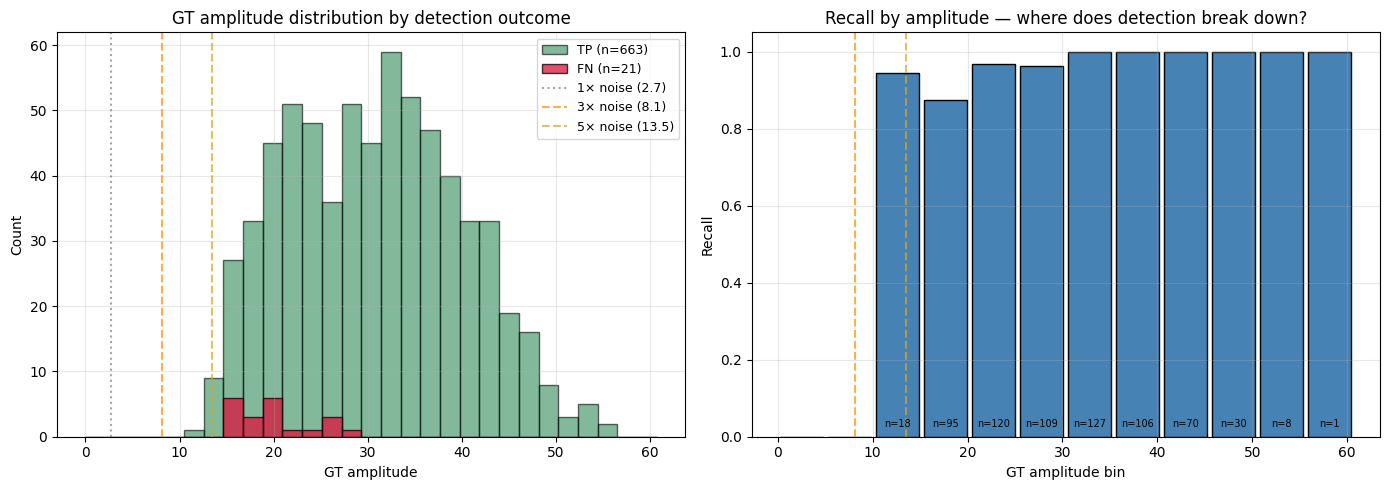


  THRESHOLD SWEEP (cv2 detector, mask on)
  thr=0.010: TP= 654 FP=   6 FN=  30  P=0.991 R=0.956 F1=0.973
  thr=0.020: TP= 655 FP=   3 FN=  29  P=0.995 R=0.958 F1=0.976
  thr=0.030: TP= 658 FP=   3 FN=  26  P=0.995 R=0.962 F1=0.978
  thr=0.050: TP= 663 FP=   4 FN=  21  P=0.994 R=0.969 F1=0.981
  thr=0.070: TP= 665 FP=   1 FN=  19  P=0.998 R=0.972 F1=0.985
  thr=0.100: TP= 657 FP=   0 FN=  27  P=1.000 R=0.961 F1=0.980
  thr=0.150: TP= 638 FP=   0 FN=  46  P=1.000 R=0.933 F1=0.965
  thr=0.250: TP= 536 FP=   0 FN= 148  P=1.000 R=0.784 F1=0.879


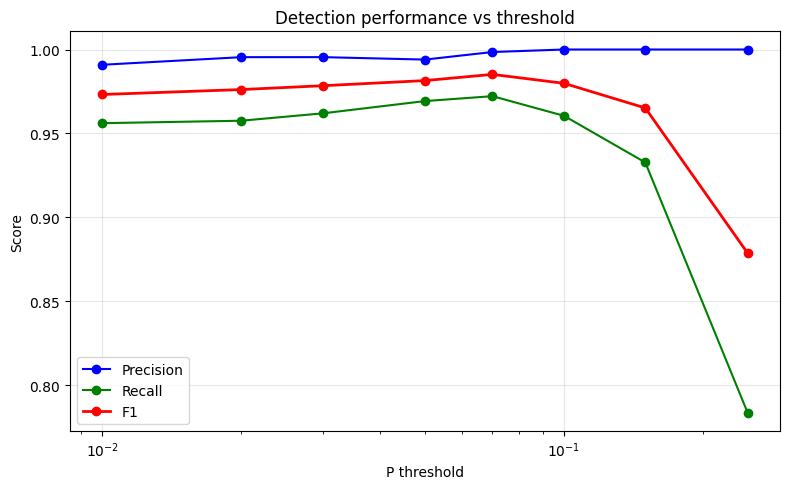


  Best F1=0.985 at threshold=0.070


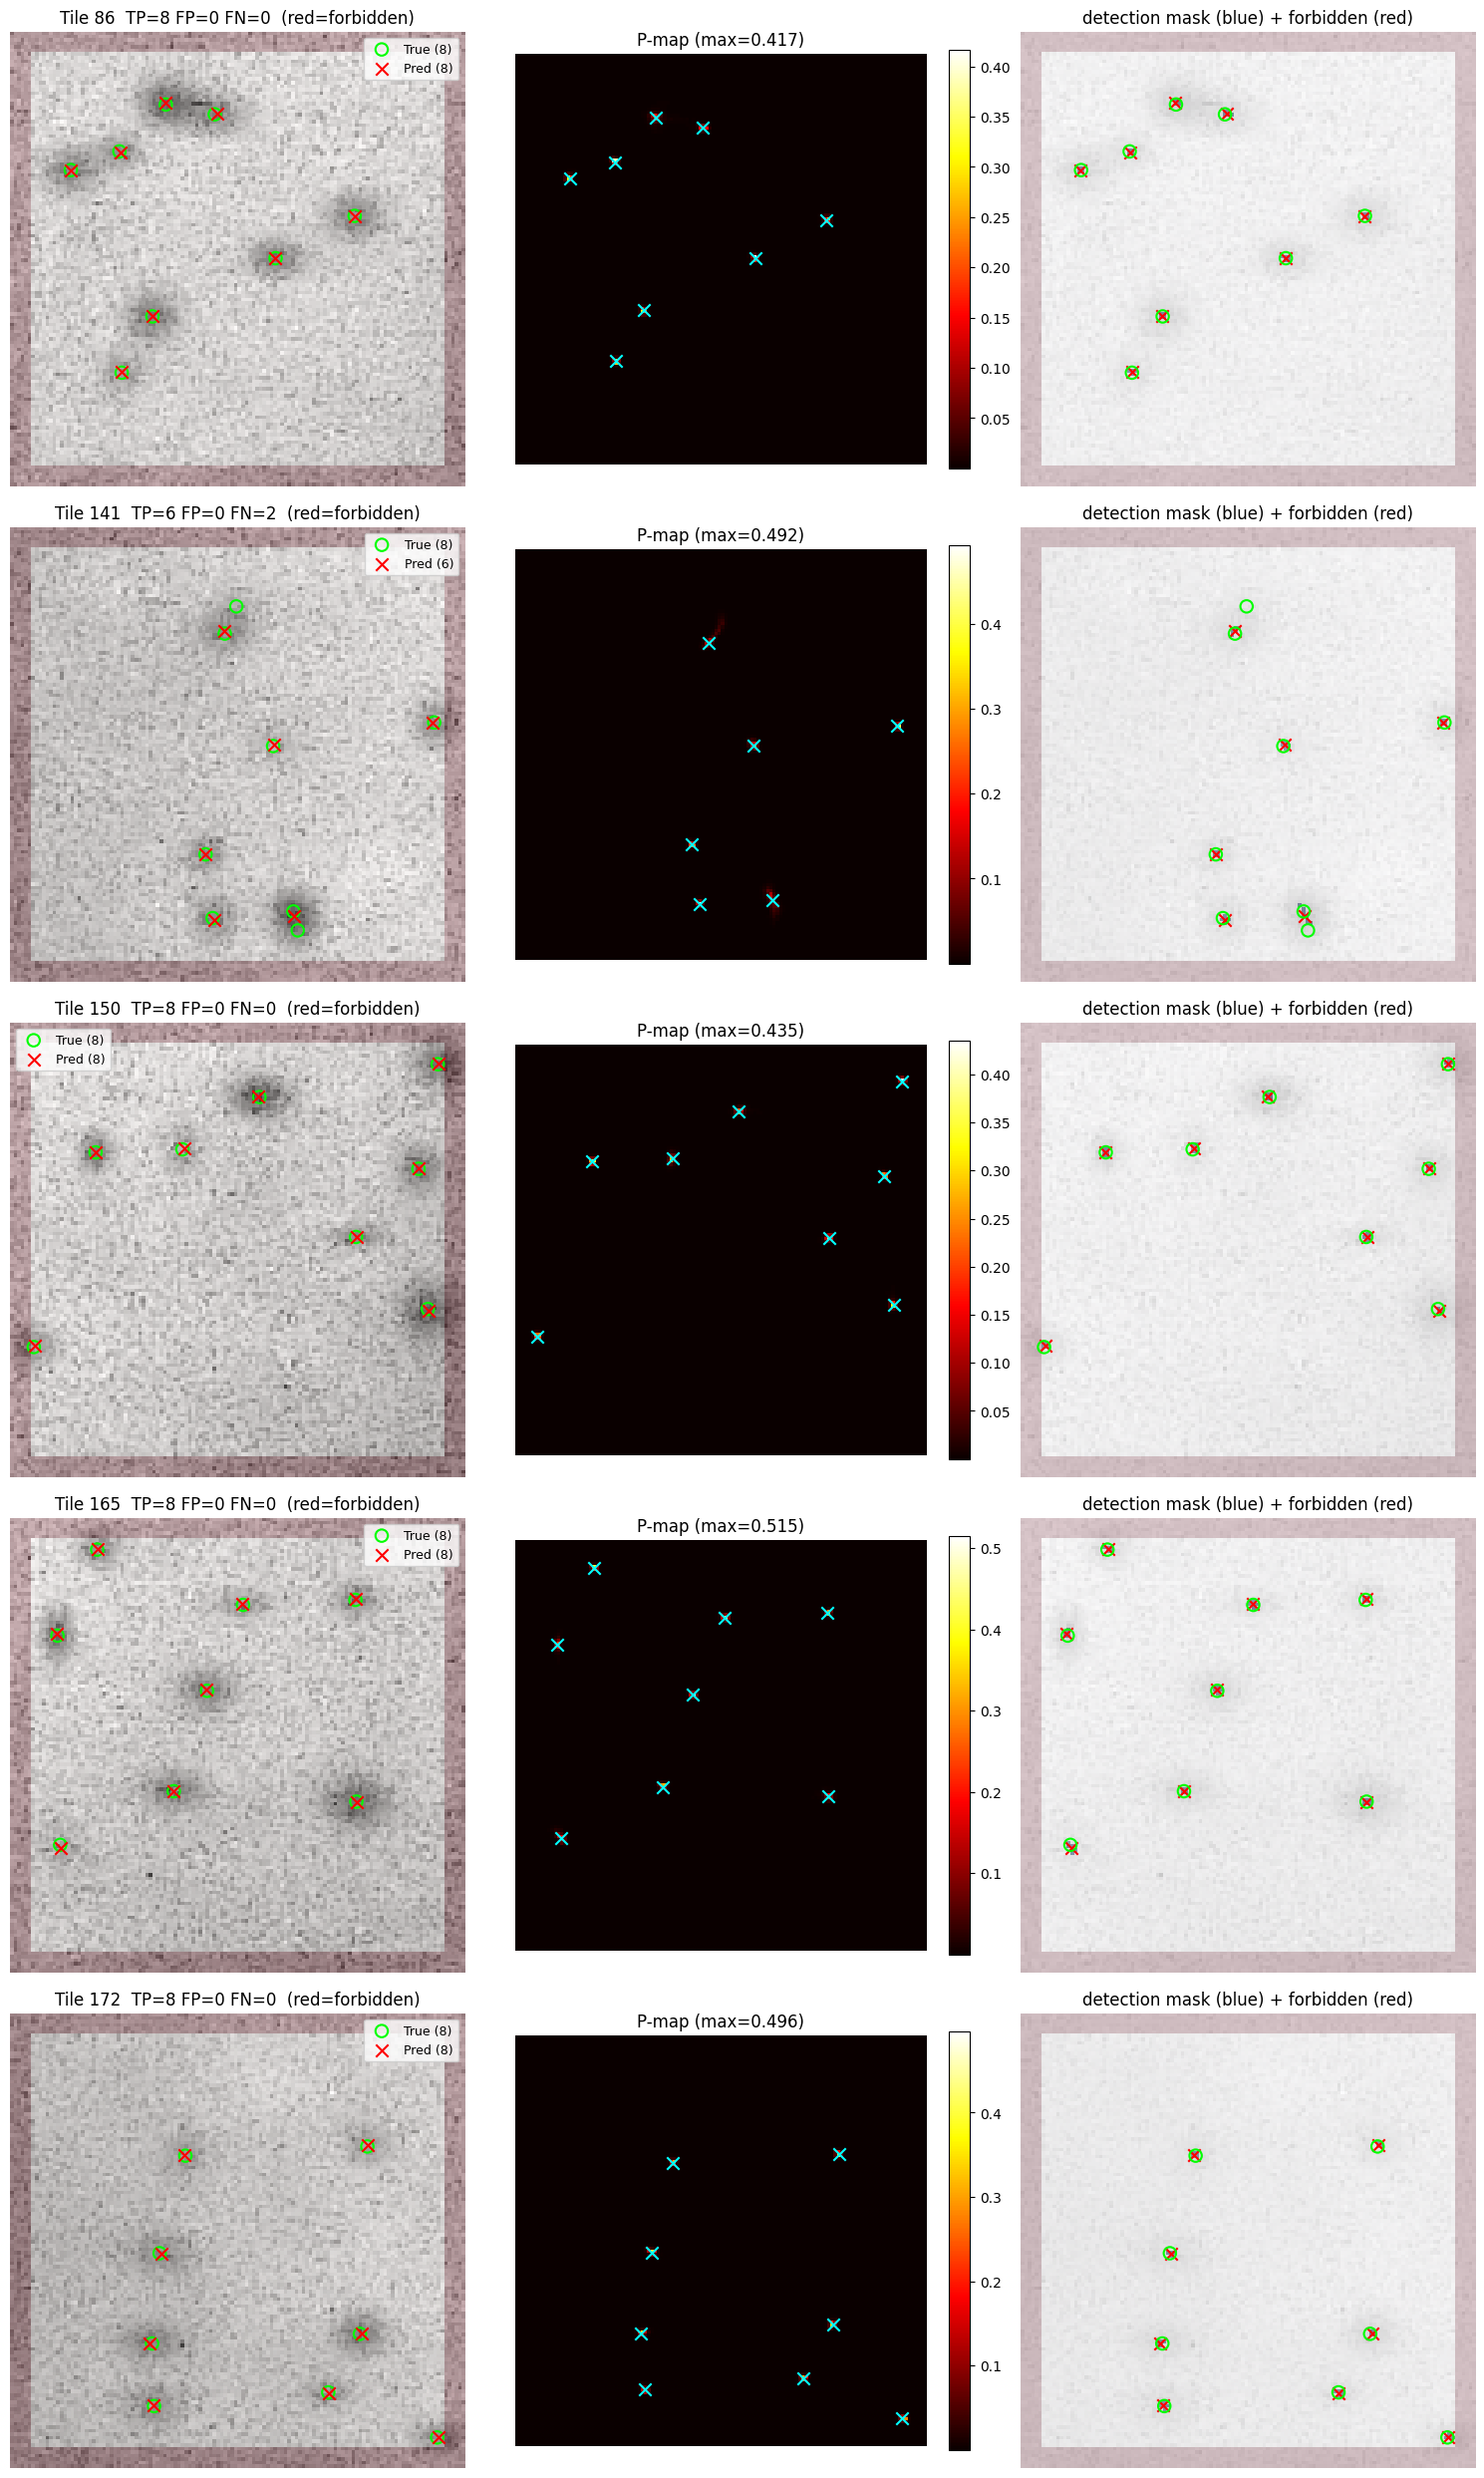

In [13]:
###############################################################################
# VALIDATION TEST — bg_tiles_train + training-matched particle density
#
# DETECTOR: OpenCV connected-components (cv2.connectedComponentsWithStats)
#   - Marker-region suppression: pixels within BUFFER_PX of any marker pixel
#     AND pixels within MARGIN of tile edge are forced to 0 before detection
#     (mirrors training's compute_forbidden_mask — particles aren't placed
#     there during training, so detections there are guaranteed FPs)
#   - Forbidden mask via cv2.distanceTransform (C++, fastest CPU path)
#   - Mask + threshold combined in one bool op — no p_map copy
###############################################################################
import os, time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage as ndi   # scipy CC kept for benchmark only


MARKER_THRESHOLD = 15


def synthesize_test_tile(bg_tile, num_gaus_low, num_gaus_high):
    """Particle synthesis that returns amplitudes alongside positions."""
    H, W = bg_tile.shape
    image = bg_tile.copy().astype(np.float32)

    forbidden = compute_forbidden_mask(bg_tile)
    if MARGIN > 0:
        forbidden[:MARGIN, :] = True
        forbidden[-MARGIN:, :] = True
        forbidden[:, :MARGIN] = True
        forbidden[:, -MARGIN:] = True
    pys, pxs = np.where(~forbidden)
    active_frac = pys.size / forbidden.size

    nominal = np.random.randint(num_gaus_low, num_gaus_high)
    scaled = nominal * active_frac
    n_floor = int(scaled)
    n_place = n_floor + (1 if np.random.random() < (scaled - n_floor) else 0)
    if pys.size == 0:
        n_place = 0

    positions, amplitudes = [], []
    x_vec = np.arange(W); y_vec = np.arange(H)

    for _ in range(n_place):
        k = np.random.randint(0, pys.size)
        x_c = pxs[k] + np.random.uniform(0, 1)
        y_c = pys[k] + np.random.uniform(0, 1)
        amp = float(sample_amplitude())
        sx = max(SIGMA_MIN, np.random.normal(loc=SIGMA_X_LOC, scale=SIGMA_X_SCALE))
        sy = max(SIGMA_MIN, np.random.normal(loc=SIGMA_Y_LOC, scale=SIGMA_Y_SCALE))
        g_x = np.exp(-((x_vec - x_c) ** 2) / (2 * sx ** 2))
        g_y = np.exp(-((y_vec - y_c) ** 2) / (2 * sy ** 2))
        image -= np.outer(g_y, g_x) * amp
        positions.append((x_c, y_c))
        amplitudes.append(amp)

    image = np.clip(image, 0, 65535)
    return (image,
            np.array(positions) if positions else np.zeros((0, 2)),
            np.array(amplitudes))


# =====================================================================
# Fast forbidden mask — matches training's compute_forbidden_mask +
# edge margin, but uses cv2.distanceTransform (~5–10× faster than scipy)
# =====================================================================
def compute_forbidden_mask_fast(image, buffer_px=None, threshold=None, margin=None):
    """Forbidden = pixels within buffer_px of any marker pixel, OR within
    margin of tile edge. Same definition as training, faster impl."""
    if buffer_px is None: buffer_px = BUFFER_PX
    if threshold is None: threshold = MARKER_THRESHOLD
    if margin is None:    margin = MARGIN

    H, W = image.shape
    # distanceTransform measures distance FROM 0-pixels; non_marker=1 elsewhere
    non_marker = (image > threshold).astype(np.uint8)

    if non_marker.all():
        forbidden = np.zeros((H, W), dtype=bool)
    else:
        # All non-zero pixels get filled with distance to nearest 0-pixel
        dist = cv2.distanceTransform(non_marker, cv2.DIST_L2, 3)
        forbidden = dist <= buffer_px

    if margin > 0:
        forbidden[:margin, :]  = True
        forbidden[-margin:, :] = True
        forbidden[:, :margin]  = True
        forbidden[:, -margin:] = True
    return forbidden


# =====================================================================
# PRIMARY DETECTOR — cv2 CC, with marker suppression baked in
# =====================================================================
def detect_via_cv2(p_map_np, forbidden_mask, p_threshold,
                   min_area=1, connectivity=8):
    """OpenCV CC. Combines threshold + forbidden-region mask in one bool
    op so no p_map copy is needed. Returns geometric centroids."""
    # (p > thr) AND (not forbidden) — both bool, single C-loop fusion in numpy
    binary = ((p_map_np > p_threshold) & ~forbidden_mask).astype(np.uint8)
    n_labels, _, stats, centroids = cv2.connectedComponentsWithStats(
        binary, connectivity=connectivity)
    if n_labels <= 1:
        return np.array([]), np.array([])
    areas = stats[1:, cv2.CC_STAT_AREA]
    keep = areas >= min_area
    cx = centroids[1:, 0][keep]
    cy = centroids[1:, 1][keep]
    return cx, cy


# =====================================================================
# BENCHMARK-ONLY DETECTORS — also take the forbidden mask so the
# comparison is apples-to-apples
# =====================================================================
def detect_via_components(p_map_np, forbidden_mask, p_threshold):
    """scipy CC + p-weighted centroid."""
    binary = (p_map_np > p_threshold) & ~forbidden_mask
    if not binary.any():
        return np.array([]), np.array([])
    labeled, n = ndi.label(binary)
    idx = np.arange(1, n + 1)
    centroids = ndi.center_of_mass(p_map_np, labeled, idx)
    cy, cx = np.array(centroids).T
    return cx, cy


def detect_peaks_nms(p_tensor, mu_tensor, forbidden_tensor, p_threshold):
    """Single-shot NMS via max-pool, with on-device forbidden mask."""
    p4 = p_tensor.unsqueeze(0).unsqueeze(0)
    p_max = F.max_pool2d(p4, kernel_size=3, stride=1, padding=1)
    peaks = (p4 == p_max) & (p4 > p_threshold)
    if forbidden_tensor is not None:
        peaks = peaks & ~forbidden_tensor.unsqueeze(0).unsqueeze(0)
    yi, xi = torch.where(peaks[0, 0])
    if yi.numel() == 0:
        return np.array([]), np.array([]), np.array([])
    mu_x = mu_tensor[0, yi, xi]
    mu_y = mu_tensor[1, yi, xi]
    refined_x = (xi.float() + mu_x + 0.5).cpu().numpy()
    refined_y = (yi.float() + mu_y + 0.5).cpu().numpy()
    peak_p = p_tensor[yi, xi].cpu().numpy()
    return refined_x, refined_y, peak_p


def match_detections_fast(true_pos, pred_x, pred_y, match_radius=10):
    if len(true_pos) == 0:
        return 0, len(pred_x), 0, []
    if len(pred_x) == 0:
        return 0, 0, len(true_pos), []
    matched = set(); out = []
    for pi in range(len(pred_x)):
        d = np.hypot(true_pos[:, 0] - pred_x[pi], true_pos[:, 1] - pred_y[pi])
        for ti in np.argsort(d):
            if d[ti] > match_radius: break
            if ti not in matched:
                matched.add(ti); out.append((ti, pi, d[ti])); break
    tp = len(out)
    return tp, len(pred_x) - tp, len(true_pos) - tp, out


def run_validation_test(model, device, bg_tiles, num_test_tiles=200,
                        p_threshold=0.05, match_radius=10,
                        num_gaus_low=0, num_gaus_high=10,
                        noise_floor=2.7, min_area=1,
                        show_examples=5,
                        threshold_sweep=True, amplitude_analysis=True,
                        runtime_benchmark=True):
    model.eval()
    np.random.seed(42)

    per_tile = []
    t_gen = t_norm = t_infer = t_mask = t_detect = t_match = 0.0

    print(f"Running {num_test_tiles} tiles, num_gaus in [{num_gaus_low}, {num_gaus_high})...")
    print(f"Detector: cv2.connectedComponentsWithStats (min_area={min_area})")
    print(f"Suppression: marker-buffer ({BUFFER_PX}px) + edge ({MARGIN}px) — "
          f"matches training forbidden mask")

    for ti in range(num_test_tiles):
        # 1. Generate
        t0 = time.time()
        bg_idx = np.random.randint(len(bg_tiles))
        bg_tile = bg_tiles[bg_idx]
        image, true_pos, true_amp = synthesize_test_tile(
            bg_tile, num_gaus_low, num_gaus_high)
        t_gen += time.time() - t0

        # 2. Normalize
        t0 = time.time()
        valid = image > MARKER_THRESHOLD
        if valid.any():
            m, s = image[valid].mean(), image[valid].std()
        else:
            m, s = image.mean(), image.std()
        if s == 0: s = 1
        img_n = (image - m) / s
        t_norm += time.time() - t0

        # 3. Inference
        t0 = time.time()
        x = torch.from_numpy(img_n).float().unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            p, pxy_mean, _, _ = model(x, training=False)
        p_dev = p[0, 0]
        mu_dev = pxy_mean[0, :2]
        t_infer += time.time() - t0
        p_map_np = p_dev.cpu().numpy()

        # 4. Forbidden mask (from raw input — Pi-realistic; no bg ref needed)
        t0 = time.time()
        forbidden = compute_forbidden_mask_fast(image)
        t_mask += time.time() - t0

        # 5. Detect (cv2 CC, mask suppresses forbidden region)
        t0 = time.time()
        cx, cy = detect_via_cv2(p_map_np, forbidden, p_threshold, min_area=min_area)
        t_detect += time.time() - t0

        # 6. Match
        t0 = time.time()
        tp, fp, fn, matches = match_detections_fast(
            true_pos, cx, cy, match_radius=match_radius)
        t_match += time.time() - t0

        per_tile.append({
            'tile_i': ti, 'image': image,
            'p_map': p_map_np,
            'p_dev': p_dev.detach(), 'mu_dev': mu_dev.detach(),
            'forbidden': forbidden,
            'true_pos': true_pos, 'true_amp': true_amp,
            'pred_x': cx, 'pred_y': cy,
            'tp': tp, 'fp': fp, 'fn': fn, 'matches': matches,
        })

    # ---- aggregate ----
    TP = sum(r['tp'] for r in per_tile)
    FP = sum(r['fp'] for r in per_tile)
    FN = sum(r['fn'] for r in per_tile)
    P  = TP / (TP + FP) if TP + FP > 0 else 0
    R  = TP / (TP + FN) if TP + FN > 0 else 0
    F1 = 2 * P * R / (P + R) if P + R > 0 else 0
    all_d = [m[2] for r in per_tile for m in r['matches']]

    print(f"\n{'='*60}\n  AGGREGATE (thr={p_threshold}, radius={match_radius}px)\n{'='*60}")
    print(f"  Tiles: {num_test_tiles}   True: {sum(len(r['true_pos']) for r in per_tile)}   "
          f"Detected: {sum(len(r['pred_x']) for r in per_tile)}")
    print(f"  TP={TP}  FP={FP}  FN={FN}")
    print(f"  Precision={P:.3f}   Recall={R:.3f}   F1={F1:.3f}")
    if all_d:
        print(f"  Localization error  mean={np.mean(all_d):.2f}   median={np.median(all_d):.2f} px")

    # ---- timing ----
    n = num_test_tiles
    print(f"\n{'='*60}\n  TIMING per tile (ms) — Pi real-time target\n{'='*60}")
    print(f"  generate:  {t_gen/n*1000:7.2f}   (test-only)")
    print(f"  normalize: {t_norm/n*1000:7.2f}")
    print(f"  inference: {t_infer/n*1000:7.2f}")
    print(f"  mask:      {t_mask/n*1000:7.2f}   ← cv2.distanceTransform")
    print(f"  detect:    {t_detect/n*1000:7.2f}   ← cv2 CC + bool fusion")
    print(f"  match:     {t_match/n*1000:7.2f}   (test-only)")
    pi_total = (t_norm + t_infer + t_mask + t_detect) / n * 1000
    print(f"  ----")
    print(f"  Pi pipeline (norm + infer + mask + detect): {pi_total:.2f} ms/tile "
          f"→ {1000/pi_total:.1f} tiles/sec")

    # ---- DETECTION BENCHMARK: NMS vs scipy-CC vs cv2-CC (all with mask) ----
    if runtime_benchmark:
        N_RUNS = 5
        # Pre-cache CPU tensors + forbidden tensors
        for r in per_tile:
            r['p_cpu']  = r['p_dev'].cpu()
            r['mu_cpu'] = r['mu_dev'].cpu()
            r['forbidden_dev'] = torch.from_numpy(r['forbidden']).to(device)
            r['forbidden_cpu'] = torch.from_numpy(r['forbidden'])

        # Warm-up
        for r in per_tile[:5]:
            detect_peaks_nms(r['p_dev'], r['mu_dev'], r['forbidden_dev'], p_threshold)
            detect_peaks_nms(r['p_cpu'], r['mu_cpu'], r['forbidden_cpu'], p_threshold)
            detect_via_components(r['p_map'], r['forbidden'], p_threshold)
            detect_via_cv2(r['p_map'], r['forbidden'], p_threshold, min_area)

        # NMS on test device
        t0 = time.time()
        for _ in range(N_RUNS):
            for r in per_tile:
                detect_peaks_nms(r['p_dev'], r['mu_dev'], r['forbidden_dev'], p_threshold)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t_nms_dev = time.time() - t0

        # NMS on CPU (Pi proxy)
        t0 = time.time()
        for _ in range(N_RUNS):
            for r in per_tile:
                detect_peaks_nms(r['p_cpu'], r['mu_cpu'], r['forbidden_cpu'], p_threshold)
        t_nms_cpu = time.time() - t0

        # scipy CC on CPU
        t0 = time.time()
        for _ in range(N_RUNS):
            for r in per_tile:
                detect_via_components(r['p_map'], r['forbidden'], p_threshold)
        t_cc_cpu = time.time() - t0

        # cv2 CC on CPU
        t0 = time.time()
        for _ in range(N_RUNS):
            for r in per_tile:
                detect_via_cv2(r['p_map'], r['forbidden'], p_threshold, min_area)
        t_cv2_cpu = time.time() - t0

        nms_dev_ms = t_nms_dev / (N_RUNS * n) * 1000
        nms_cpu_ms = t_nms_cpu / (N_RUNS * n) * 1000
        cc_cpu_ms  = t_cc_cpu  / (N_RUNS * n) * 1000
        cv2_cpu_ms = t_cv2_cpu / (N_RUNS * n) * 1000

        print(f"\n{'='*60}\n  DETECTION BENCHMARK ({N_RUNS}× × {n} tiles, all with mask)\n{'='*60}")
        print(f"  NMS       on {str(device):10s}: {nms_dev_ms:7.3f} ms/tile")
        print(f"  NMS       on CPU       : {nms_cpu_ms:7.3f} ms/tile   ← Pi proxy")
        print(f"  scipy CC  on CPU       : {cc_cpu_ms:7.3f} ms/tile")
        print(f"  cv2 CC    on CPU       : {cv2_cpu_ms:7.3f} ms/tile   ← chosen")
        print(f"  ----")
        cpu_times = {'NMS': nms_cpu_ms, 'scipy CC': cc_cpu_ms, 'cv2 CC': cv2_cpu_ms}
        best_cpu = min(cpu_times, key=cpu_times.get)
        print(f"  Fastest CPU detector (Pi-relevant): {best_cpu} "
              f"({cpu_times[best_cpu]:.3f} ms/tile)")

    # ---- amplitude analysis ----
    if amplitude_analysis:
        all_tp_amps, all_fn_amps = [], []
        for r in per_tile:
            if len(r['true_amp']) == 0: continue
            matched_ti = set(m[0] for m in r['matches'])
            for ti2, amp in enumerate(r['true_amp']):
                (all_tp_amps if ti2 in matched_ti else all_fn_amps).append(amp)
        all_tp_amps = np.array(all_tp_amps)
        all_fn_amps = np.array(all_fn_amps)

        print(f"\n{'='*60}\n  GT AMPLITUDE: TP vs FN (noise floor ≈ {noise_floor})\n{'='*60}")
        if len(all_tp_amps) > 0:
            print(f"  TP (n={len(all_tp_amps)}): mean={all_tp_amps.mean():.2f}  "
                  f"median={np.median(all_tp_amps):.2f}  "
                  f"min={all_tp_amps.min():.2f}  max={all_tp_amps.max():.2f}")
        if len(all_fn_amps) > 0:
            print(f"  FN (n={len(all_fn_amps)}): mean={all_fn_amps.mean():.2f}  "
                  f"median={np.median(all_fn_amps):.2f}  "
                  f"min={all_fn_amps.min():.2f}  max={all_fn_amps.max():.2f}")
            for k in [2, 3, 5]:
                below = (all_fn_amps < k * noise_floor).sum()
                print(f"  FNs below {k}× noise (amp < {k*noise_floor:.1f}): "
                      f"{below}/{len(all_fn_amps)} ({below/len(all_fn_amps)*100:.1f}%)")

        if len(all_tp_amps) + len(all_fn_amps) > 0:
            all_amps = np.concatenate([all_tp_amps, all_fn_amps])
            all_hit  = np.concatenate([np.ones(len(all_tp_amps)),
                                       np.zeros(len(all_fn_amps))])
            findable = all_amps >= 3 * noise_floor
            if findable.sum() > 0:
                rec_findable = all_hit[findable].mean()
                print(f"\n  Recall on findable (amp ≥ 3× noise = {3*noise_floor:.1f}): "
                      f"{rec_findable:.3f}  "
                      f"({int(all_hit[findable].sum())}/{int(findable.sum())})")

        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        max_amp = max(
            all_tp_amps.max() if len(all_tp_amps) > 0 else 60,
            all_fn_amps.max() if len(all_fn_amps) > 0 else 60)
        bins = np.linspace(0, max_amp + 5, 30)

        ax[0].hist(all_tp_amps, bins=bins, alpha=0.6, color='seagreen',
                   label=f'TP (n={len(all_tp_amps)})', edgecolor='black')
        if len(all_fn_amps) > 0:
            ax[0].hist(all_fn_amps, bins=bins, alpha=0.75, color='crimson',
                       label=f'FN (n={len(all_fn_amps)})', edgecolor='black')
        for k, color, ls in [(1, 'gray', ':'), (3, 'darkorange', '--'),
                             (5, 'goldenrod', '--')]:
            ax[0].axvline(k * noise_floor, ls=ls, color=color, alpha=0.7,
                          label=f'{k}× noise ({k*noise_floor:.1f})')
        ax[0].set_xlabel('GT amplitude'); ax[0].set_ylabel('Count')
        ax[0].set_title('GT amplitude distribution by detection outcome')
        ax[0].legend(fontsize=9, loc='upper right'); ax[0].grid(alpha=0.3)

        if len(all_fn_amps) > 0 and len(all_tp_amps) > 0:
            bin_edges = np.linspace(0, max_amp + 5, 13)
            centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            width = bin_edges[1] - bin_edges[0]
            rates, counts = [], []
            for i in range(len(centers)):
                mm = (all_amps >= bin_edges[i]) & (all_amps < bin_edges[i+1])
                cnt = mm.sum()
                rates.append(all_hit[mm].mean() if cnt > 0 else 0)
                counts.append(cnt)
            ax[1].bar(centers, rates, width=width*0.9,
                      color='steelblue', edgecolor='black')
            for c, cnt in zip(centers, counts):
                if cnt > 0:
                    ax[1].text(c, 0.02, f'n={cnt}',
                               ha='center', va='bottom', fontsize=7)
            for k, color in [(3, 'darkorange'), (5, 'goldenrod')]:
                ax[1].axvline(k * noise_floor, ls='--', color=color, alpha=0.7)
            ax[1].set_xlabel('GT amplitude bin'); ax[1].set_ylabel('Recall')
            ax[1].set_title('Recall by amplitude — where does detection break down?')
            ax[1].set_ylim([0, 1.05]); ax[1].grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    # ---- threshold sweep (with mask) ----
    if threshold_sweep:
        print(f"\n{'='*60}\n  THRESHOLD SWEEP (cv2 detector, mask on)\n{'='*60}")
        thrs = [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.25]
        sweep = []
        for thr in thrs:
            tp_s = fp_s = fn_s = 0
            for r in per_tile:
                cx, cy = detect_via_cv2(r['p_map'], r['forbidden'], thr,
                                        min_area=min_area)
                t, f, n_, _ = match_detections_fast(r['true_pos'], cx, cy, match_radius)
                tp_s += t; fp_s += f; fn_s += n_
            p_s = tp_s / (tp_s + fp_s) if tp_s + fp_s > 0 else 0
            r_s = tp_s / (tp_s + fn_s) if tp_s + fn_s > 0 else 0
            f1_s = 2 * p_s * r_s / (p_s + r_s) if p_s + r_s > 0 else 0
            sweep.append((thr, tp_s, fp_s, fn_s, p_s, r_s, f1_s))
            print(f"  thr={thr:.3f}: TP={tp_s:4d} FP={fp_s:4d} FN={fn_s:4d}  "
                  f"P={p_s:.3f} R={r_s:.3f} F1={f1_s:.3f}")

        fig, ax = plt.subplots(figsize=(8, 5))
        x_t = [s[0] for s in sweep]
        ax.plot(x_t, [s[4] for s in sweep], 'b-o', label='Precision')
        ax.plot(x_t, [s[5] for s in sweep], 'g-o', label='Recall')
        ax.plot(x_t, [s[6] for s in sweep], 'r-o', lw=2, label='F1')
        ax.set_xscale('log'); ax.set_xlabel('P threshold'); ax.set_ylabel('Score')
        ax.set_title('Detection performance vs threshold'); ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()
        best = max(sweep, key=lambda s: s[6])
        print(f"\n  Best F1={best[6]:.3f} at threshold={best[0]:.3f}")

    # ---- example tiles ----
    if show_examples > 0:
        per_tile.sort(key=lambda r: len(r['true_pos']), reverse=True)
        ex = per_tile[:show_examples]
        fig, axes = plt.subplots(show_examples, 3, figsize=(15, 5*show_examples))
        if show_examples == 1: axes = axes[np.newaxis, :]
        for row, r in enumerate(ex):
            # A: image + GT + predictions + forbidden overlay
            axes[row, 0].imshow(r['image'], cmap='gray', interpolation='none')
            axes[row, 0].imshow(r['forbidden'], cmap='Reds', alpha=0.25,
                                interpolation='none')
            if len(r['true_pos']) > 0:
                axes[row, 0].scatter(r['true_pos'][:, 0], r['true_pos'][:, 1],
                                     facecolors='none', edgecolors='lime', s=80, lw=1.5,
                                     label=f"True ({len(r['true_pos'])})")
            if len(r['pred_x']) > 0:
                axes[row, 0].scatter(r['pred_x'], r['pred_y'], color='red', marker='x',
                                     s=80, lw=1.5, label=f"Pred ({len(r['pred_x'])})")
            axes[row, 0].legend(fontsize=9)
            axes[row, 0].set_title(f"Tile {r['tile_i']}  TP={r['tp']} FP={r['fp']} FN={r['fn']}  "
                                   f"(red=forbidden)")
            axes[row, 0].axis('off')

            # B: p-map with peak markers
            im = axes[row, 1].imshow(r['p_map'], cmap='hot', interpolation='none')
            if len(r['pred_x']) > 0:
                axes[row, 1].scatter(r['pred_x'], r['pred_y'], color='cyan', marker='x',
                                     s=80, lw=1.5)
            axes[row, 1].set_title(f"P-map (max={r['p_map'].max():.3f})")
            axes[row, 1].axis('off')
            fig.colorbar(im, ax=axes[row, 1], fraction=0.046)

            # C: detection-ready mask (p>thr AND not forbidden)
            mask = (r['p_map'] > p_threshold) & ~r['forbidden']
            axes[row, 2].imshow(r['image'], cmap='gray', alpha=0.5, interpolation='none')
            axes[row, 2].imshow(mask, cmap='Blues', alpha=0.5, interpolation='none')
            axes[row, 2].imshow(r['forbidden'], cmap='Reds', alpha=0.2,
                                interpolation='none')
            if len(r['pred_x']) > 0:
                axes[row, 2].scatter(r['pred_x'], r['pred_y'], color='red', marker='x',
                                     s=80, lw=1.5)
            if len(r['true_pos']) > 0:
                axes[row, 2].scatter(r['true_pos'][:, 0], r['true_pos'][:, 1],
                                     facecolors='none', edgecolors='lime', s=80, lw=1.5)
            axes[row, 2].set_title(f'detection mask (blue) + forbidden (red)')
            axes[row, 2].axis('off')
        plt.tight_layout(); plt.show()

    return per_tile


# ============ RUN ============
if __name__ == '__main__':
    model = GaussianMixtureModel(num_channels=1)
    model_path = os.path.join(os.getcwd(), 'pram_proper.pth')
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Loading model: {model_path}")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    print(f"Device: {device} | bg_tiles_train: {len(bg_tiles_train)} tiles")

    results = run_validation_test(
        model=model, device=device,
        bg_tiles=bg_tiles_train,
        num_test_tiles=200,
        p_threshold=0.05,
        match_radius=10,
        num_gaus_low=0, num_gaus_high=10,
        noise_floor=2.7,
        min_area=1,
        show_examples=5,
        threshold_sweep=True,
        amplitude_analysis=True,
        runtime_benchmark=True,
    )

## REAL DATA TEST

In [33]:
###############################################################################
# REAL-DATA VALIDATION — manual annotation + model comparison
#
# Workflow:
#   1. Tile the real FOVs, randomly sample N tiles (reproducible)
#   2. Annotate particle centers in napari — ONE scrollable stack, click to add
#   3. Run the model on the same tiles
#   4. Match manual (ground truth) vs model detections -> P / R / F1
#
# Requires (one-time):  pip install "napari[all]"
# Reuses from your notebook: window_size, DOWNSCALE_FACTOR, MARKER_THRESHOLD,
#   downsample_image, model, device, detect_via_cv2, match_detections_fast
###############################################################################
import os, glob
import numpy as np
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

REAL_FOLDER   = 'real_image'
N_TILES       = 100
SAMPLE_SEED   = 42
P_THRESHOLD   = 0.03
MIN_AREA      = 1
MATCH_RADIUS  = 10            # in MODEL (128) px
ANNOT_PATH    = 'manual_annotations.npy'

# native tile = model window × downscale  (128 × 2 = 256)
NATIVE_WINDOW = (window_size[0]*DOWNSCALE_FACTOR, window_size[1]*DOWNSCALE_FACTOR)

def load_real_native(path):
    """Red channel at FULL (non-downsampled) resolution."""
    arr = np.asarray(Image.open(path)).astype(np.float32)
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    return arr

def normalize_tile(image):
    valid = image > MARKER_THRESHOLD
    if valid.any():
        m, s = image[valid].mean(), image[valid].std()
    else:
        m, s = image.mean(), image.std()
    if s == 0:
        s = 1
    return (image - m) / s

def sample_real_tiles(folder, n_tiles, seed=0):
    paths = sorted(glob.glob(os.path.join(folder, '*')))
    assert paths, f"No images found in {folder}"
    rng = np.random.RandomState(seed)
    tiles, meta = [], []
    for p in paths:
        img = load_real_native(p)                     # NATIVE res, no downsample
        h, w = img.shape
        for i in range(h // NATIVE_WINDOW[0]):
            for j in range(w // NATIVE_WINDOW[1]):
                tile = img[i*NATIVE_WINDOW[0]:(i+1)*NATIVE_WINDOW[0],
                           j*NATIVE_WINDOW[1]:(j+1)*NATIVE_WINDOW[1]]
                tiles.append(tile)
                meta.append((os.path.basename(p), i, j))
    tiles = np.asarray(tiles)
    k = min(n_tiles, len(tiles))
    idx = rng.choice(len(tiles), size=k, replace=False); idx.sort()
    print(f"{len(paths)} FOVs -> {len(tiles)} native tiles; sampled {k}")
    return tiles[idx], [meta[m] for m in idx], idx

TILES_PATH = 'sampled_tiles.npz'
if os.path.exists(TILES_PATH):
    d = np.load(TILES_PATH, allow_pickle=True)
    tiles_native = d['native']    # 256, for annotation display
    tiles_raw    = d['raw']       # 128, for forbidden mask + viz
    tiles_norm   = d['norm']      # 128, for model
    tile_meta    = [tuple(m) for m in d['meta']]
    print(f"Loaded frozen tile set: {len(tiles_native)} tiles")
else:
    tiles_native, tile_meta, _ = sample_real_tiles(REAL_FOLDER, N_TILES, SAMPLE_SEED)
    tiles_raw  = np.stack([downsample_image(t) for t in tiles_native])  # 256 -> 128
    tiles_norm = np.stack([normalize_tile(t) for t in tiles_raw])       # 128 normalized
    np.savez(TILES_PATH, native=tiles_native, raw=tiles_raw, norm=tiles_norm,
             meta=np.array(tile_meta, dtype=object))
    print(f"Froze {len(tiles_native)} tiles (native {tiles_native.shape[1:]}, "
          f"model {tiles_raw.shape[1:]})")

Loaded frozen tile set: 100 tiles


In [37]:
# ---- 2. ANNOTATE IN NAPARI --------------------------------------------------
# Run this cell. A napari window opens with all tiles as a scrollable stack
# (the slider at the bottom moves between tiles).
#
#   • Select the 'manual' Points layer in the left panel.
#   • Click the "Add points" tool (the '+' marker icon).
#   • Click each particle center you can see. Move the slider to the next tile.
#   • To delete a misclick: switch to the select tool, click the point, Delete.
#
# When finished, run the SAVE cell below. (No need to get every tile perfect in
# one sitting — napari keeps points in the viewer until you close it.)
%gui qt
import napari
# Level every tile's background to a common DARK value, preserving absolute
# particle depths (no /std) — bright tiles then render like the dark tiles you
# can already read. One contrast window works for all.
bgs = np.array([np.median(t[t > MARKER_THRESHOLD]) for t in tiles_native])
TARGET_BG = float(np.percentile(bgs, 20))      # a dark background level you're used to

def level_bg(tile):
    bg = np.median(tile[tile > MARKER_THRESHOLD])   # robust bg, ignores markers
    return tile - bg + TARGET_BG

tiles_disp = np.stack([level_bg(t) for t in tiles_native])

viewer = napari.Viewer()
viewer.add_image(tiles_disp, name='tiles', colormap='red',
                 contrast_limits=[TARGET_BG - 60, TARGET_BG + 15])   # nudge low end to taste
pts = viewer.add_points(name='manual', ndim=3, size=6,
                        face_color='transparent', border_color='cyan', symbol='x')
pts.mode = 'add'

In [38]:
# ---- SAVE ANNOTATIONS -------------------------------------------------------
# napari Points in a 3D stack come out as (n_points, 3): [tile_index, y, x]
manual_points = np.asarray(viewer.layers['manual'].data).copy()
np.save(ANNOT_PATH, manual_points)
n_tiles_touched = len(np.unique(np.round(manual_points[:, 0]).astype(int))) \
    if len(manual_points) else 0
print(f"Saved {len(manual_points)} clicks across {n_tiles_touched} tiles "
      f"-> {ANNOT_PATH}")

Saved 284 clicks across 95 tiles -> manual_annotations.npy



  REAL-DATA VALIDATION (thr=0.03, radius=10px, mask on)
  Manual: 251   Model: 227
  TP=207  FP=20  FN=44
  Precision=0.912  Recall=0.825  F1=0.866
  Localization vs manual: mean=1.97  median=1.80 px


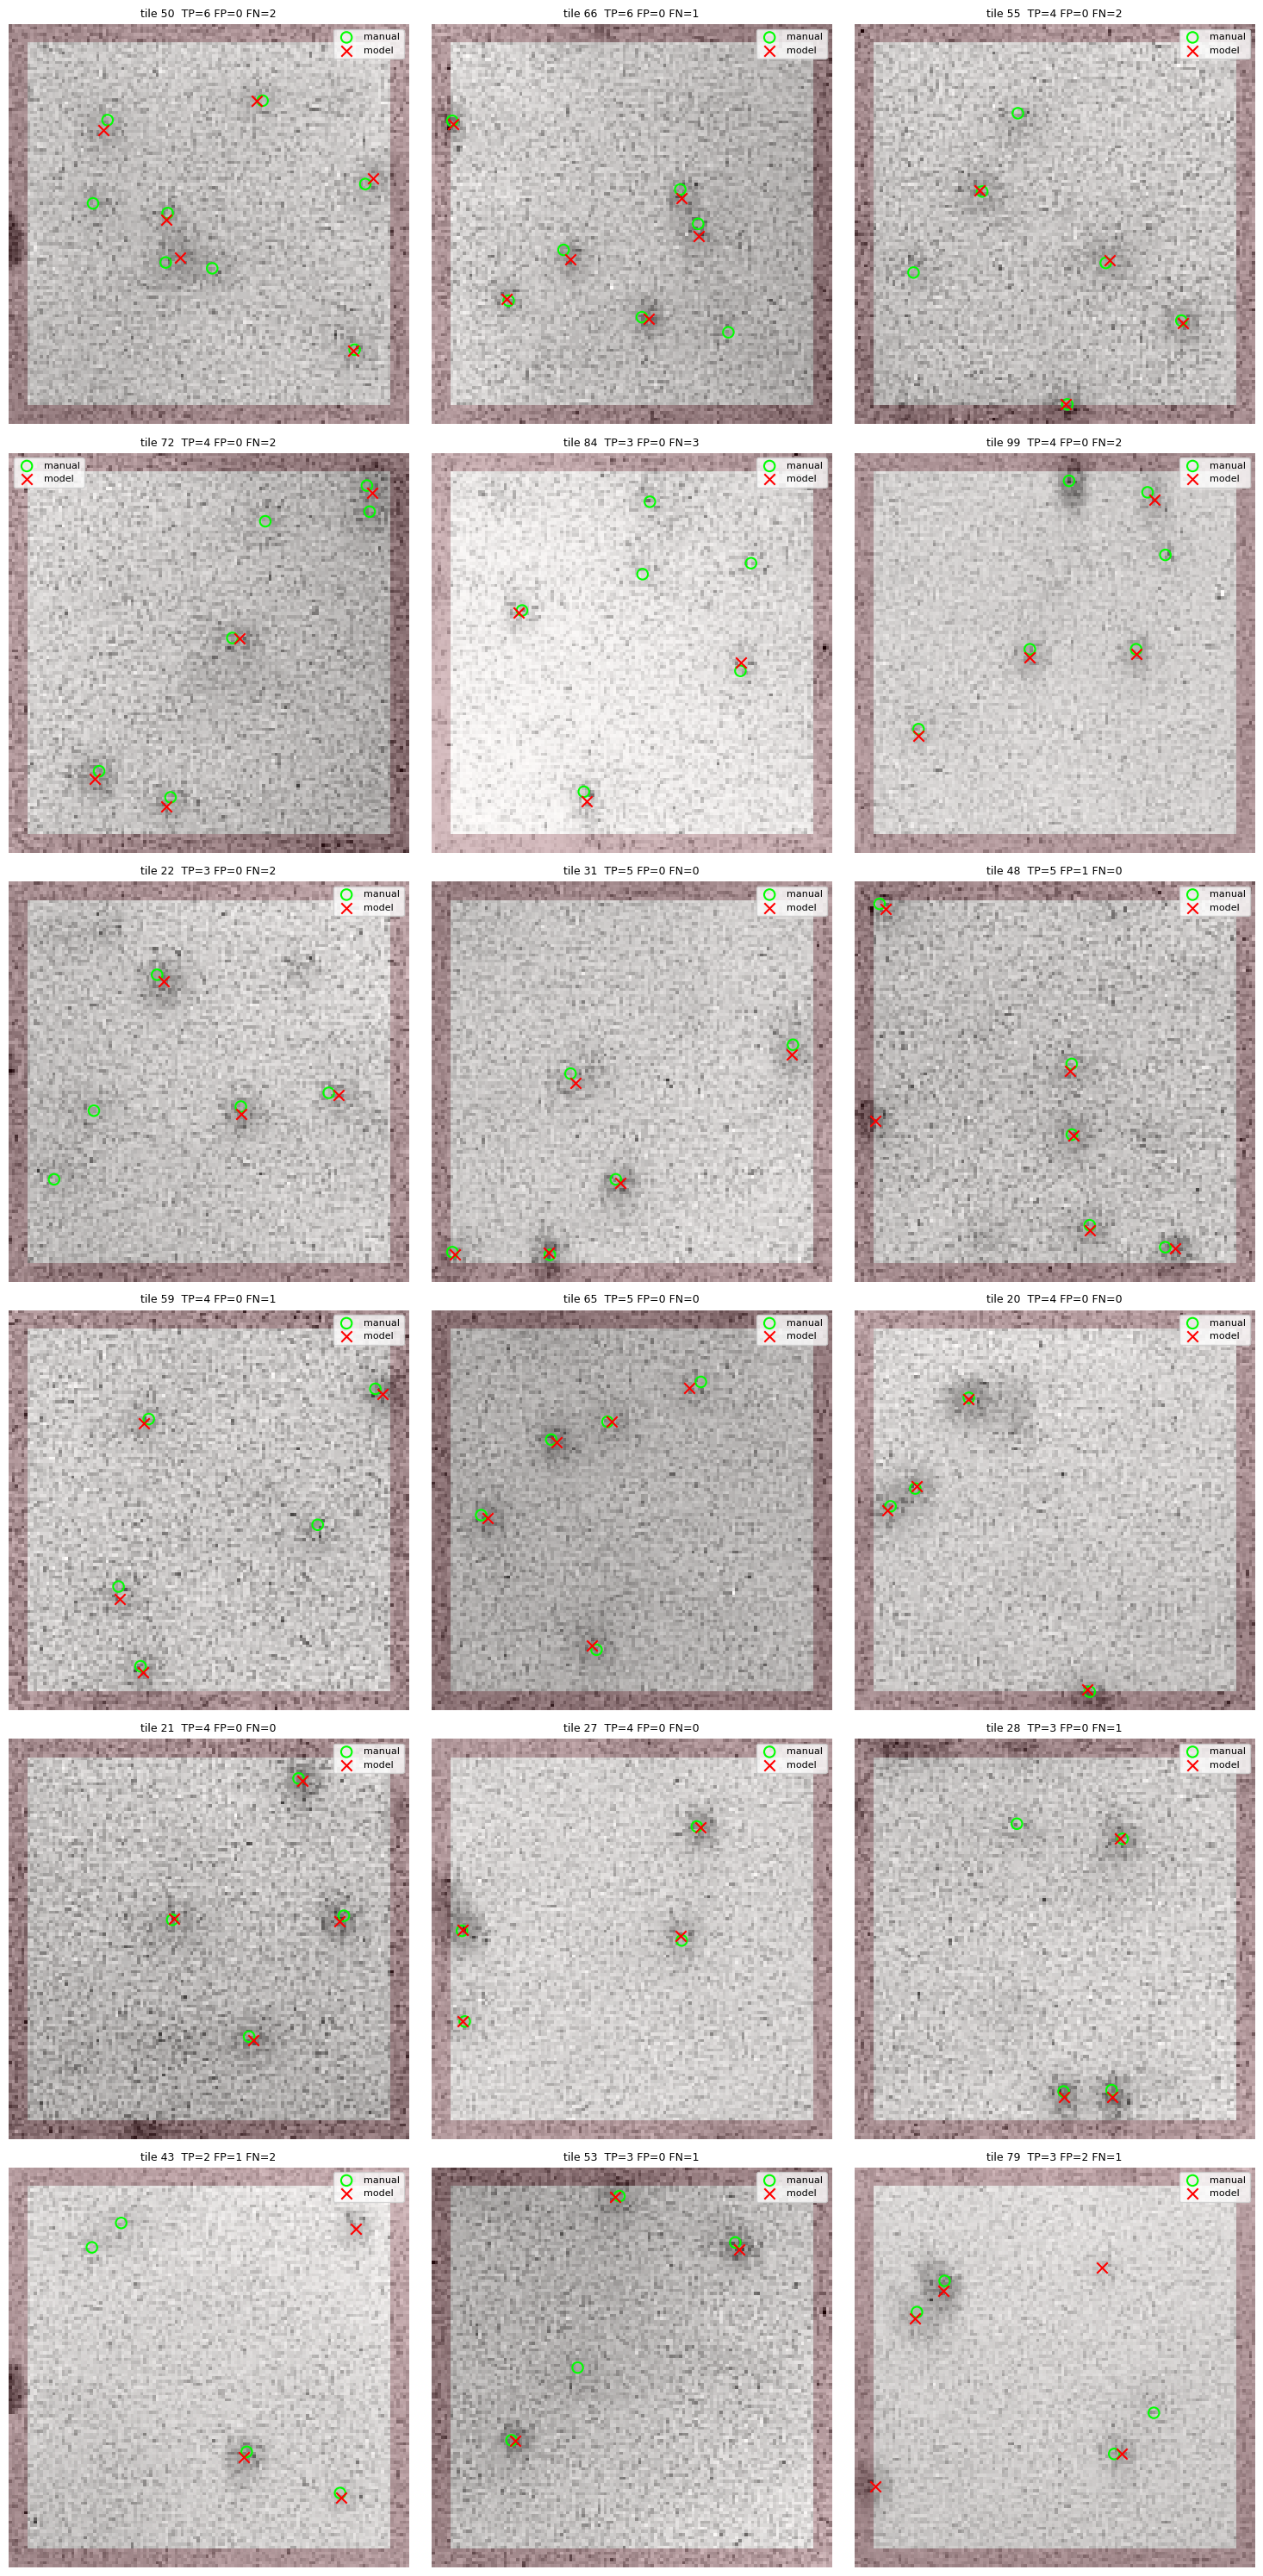


  REAL-DATA THRESHOLD SWEEP (radius=10px, mask on)
  thr=0.001: TP= 231 FP=  51 FN=  20  P=0.819 R=0.920 F1=0.867
  thr=0.002: TP= 232 FP=  52 FN=  19  P=0.817 R=0.924 F1=0.867
  thr=0.003: TP= 233 FP=  41 FN=  18  P=0.850 R=0.928 F1=0.888
  thr=0.004: TP= 231 FP=  37 FN=  20  P=0.862 R=0.920 F1=0.890
  thr=0.006: TP= 227 FP=  36 FN=  24  P=0.863 R=0.904 F1=0.883
  thr=0.008: TP= 224 FP=  36 FN=  27  P=0.862 R=0.892 F1=0.877
  thr=0.010: TP= 222 FP=  32 FN=  29  P=0.874 R=0.884 F1=0.879
  thr=0.020: TP= 210 FP=  27 FN=  41  P=0.886 R=0.837 F1=0.861
  thr=0.030: TP= 207 FP=  20 FN=  44  P=0.912 R=0.825 F1=0.866
  thr=0.050: TP= 191 FP=  15 FN=  60  P=0.927 R=0.761 F1=0.836
  thr=0.070: TP= 185 FP=  13 FN=  66  P=0.934 R=0.737 F1=0.824
  thr=0.100: TP= 173 FP=   9 FN=  78  P=0.951 R=0.689 F1=0.799
  thr=0.150: TP= 146 FP=   7 FN= 105  P=0.954 R=0.582 F1=0.723
  thr=0.250: TP=  72 FP=   3 FN= 179  P=0.960 R=0.287 F1=0.442

  Best F1=0.890 at threshold=0.004


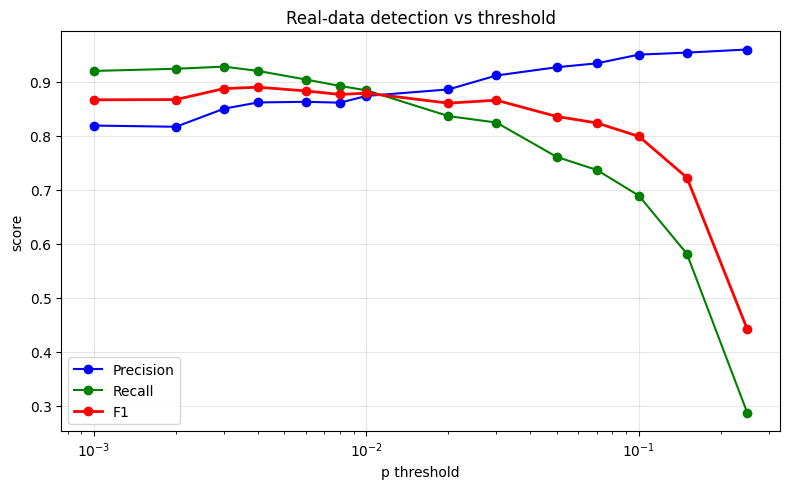

In [42]:
# ---- 3 + 4. RUN MODEL & COMPARE (forbidden-mask suppression, matches test code) ----
import torch
import numpy as np
EDGE_MARGIN_TEST = 6   # bigger edge exclusion (model/128-px units) for REAL testing only.
                        # default MARGIN ≈ 6; this widens edges for both detection and GT.

def _forbidden_for(ti):
    return compute_forbidden_mask_fast(tiles_raw[ti], margin=EDGE_MARGIN_TEST)

def _filter_manual(true_pos, forbidden):
    """Drop manual clicks inside the forbidden region. The model is designed not
    to detect there (training placed no particles there), so counting them as FN
    would be unfair — and inconsistent with the synthetic test, which never has
    GT particles in forbidden regions."""
    if not len(true_pos):
        return true_pos
    yy = np.clip(true_pos[:, 1].astype(int), 0, forbidden.shape[0] - 1)
    xx = np.clip(true_pos[:, 0].astype(int), 0, forbidden.shape[1] - 1)
    return true_pos[~forbidden[yy, xx]]


def compare_to_manual(annot_path=ANNOT_PATH, p_threshold=P_THRESHOLD,
                      min_area=MIN_AREA, match_radius=MATCH_RADIUS, visualize_n=18):
    model.eval()
    manual_points = np.load(annot_path)
    manual_by_tile = {ti: [] for ti in range(len(tiles_raw))}
    for slc, y, x in manual_points:
        ti = int(round(slc))
        if 0 <= ti < len(tiles_raw):
            manual_by_tile[ti].append((x / DOWNSCALE_FACTOR, y / DOWNSCALE_FACTOR))

    TP = FP = FN = 0
    all_d, per_tile = [], []
    for ti in range(len(tiles_raw)):
        x_in = torch.from_numpy(tiles_norm[ti]).float().unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            p, _, _, _ = model(x_in, training=False)
        p_map = p[0, 0].cpu().numpy()
        forbidden = _forbidden_for(ti)
        cx, cy = detect_via_cv2(p_map, forbidden, p_threshold, min_area=min_area)

        true_pos = (np.asarray(manual_by_tile[ti]) if manual_by_tile[ti]
                    else np.zeros((0, 2)))
        true_pos = _filter_manual(true_pos, forbidden)
        tp, fp, fn, matches = match_detections_fast(true_pos, cx, cy, match_radius)
        TP += tp; FP += fp; FN += fn
        all_d += [m[2] for m in matches]
        per_tile.append((ti, p_map, forbidden, true_pos, cx, cy, tp, fp, fn))

    P  = TP / (TP + FP) if TP + FP else 0
    R  = TP / (TP + FN) if TP + FN else 0
    F1 = 2 * P * R / (P + R) if P + R else 0
    print(f"\n{'='*60}\n  REAL-DATA VALIDATION (thr={p_threshold}, radius={match_radius}px, mask on)\n{'='*60}")
    print(f"  Manual: {TP+FN}   Model: {TP+FP}")
    print(f"  TP={TP}  FP={FP}  FN={FN}")
    print(f"  Precision={P:.3f}  Recall={R:.3f}  F1={F1:.3f}")
    if all_d:
        print(f"  Localization vs manual: mean={np.mean(all_d):.2f}  median={np.median(all_d):.2f} px")

    if visualize_n > 0:
        import matplotlib.pyplot as plt
        per_tile.sort(key=lambda r: len(r[3]), reverse=True)
        ex = per_tile[:visualize_n]
        cols = 3; rows = (len(ex) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
        axes = np.atleast_1d(axes).ravel()
        for ax, (ti, p_map, forbidden, tpos, cx, cy, tp, fp, fn) in zip(axes, ex):
            ax.imshow(tiles_raw[ti], cmap='gray', interpolation='none')
            ax.imshow(forbidden, cmap='Reds', alpha=0.25, interpolation='none')
            if len(tpos):
                ax.scatter(tpos[:, 0], tpos[:, 1], facecolors='none',
                           edgecolors='lime', s=80, lw=1.5, label='manual')
            if len(cx):
                ax.scatter(cx, cy, color='red', marker='x', s=80, lw=1.5, label='model')
            ax.set_title(f"tile {ti}  TP={tp} FP={fp} FN={fn}", fontsize=9)
            ax.legend(fontsize=8); ax.axis('off')
        for ax in axes[len(ex):]:
            ax.axis('off')
        plt.tight_layout(); plt.show()
    return dict(TP=TP, FP=FP, FN=FN, P=P, R=R, F1=F1)


def sweep_real(annot_path=ANNOT_PATH, min_area=MIN_AREA, match_radius=MATCH_RADIUS,
               thrs=(0.001, 0.002, 0.003, 0.004, 0.006, 0.008, 0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.25)):
    model.eval()
    manual_points = np.load(annot_path)
    manual_by_tile = {ti: [] for ti in range(len(tiles_raw))}
    for slc, y, x in manual_points:
        ti = int(round(slc))
        if 0 <= ti < len(tiles_raw):
            manual_by_tile[ti].append((x / DOWNSCALE_FACTOR, y / DOWNSCALE_FACTOR))

    p_maps, forbiddens, true_by_tile = {}, {}, {}
    with torch.no_grad():
        for ti in range(len(tiles_raw)):
            x_in = torch.from_numpy(tiles_norm[ti]).float().unsqueeze(0).unsqueeze(0).to(device)
            p, _, _, _ = model(x_in, training=False)
            p_maps[ti] = p[0, 0].cpu().numpy()
            forbiddens[ti] = _forbidden_for(ti)
            tp_arr = (np.asarray(manual_by_tile[ti]) if manual_by_tile[ti]
                      else np.zeros((0, 2)))
            true_by_tile[ti] = _filter_manual(tp_arr, forbiddens[ti])

    print(f"\n{'='*64}\n  REAL-DATA THRESHOLD SWEEP (radius={match_radius}px, mask on)\n{'='*64}")
    sweep = []
    for thr in thrs:
        TP = FP = FN = 0
        for ti in range(len(tiles_raw)):
            cx, cy = detect_via_cv2(p_maps[ti], forbiddens[ti], thr, min_area=min_area)
            tp, fp, fn, _ = match_detections_fast(true_by_tile[ti], cx, cy, match_radius)
            TP += tp; FP += fp; FN += fn
        P  = TP / (TP + FP) if TP + FP else 0
        R  = TP / (TP + FN) if TP + FN else 0
        F1 = 2 * P * R / (P + R) if P + R else 0
        sweep.append((thr, TP, FP, FN, P, R, F1))
        print(f"  thr={thr:.3f}: TP={TP:4d} FP={FP:4d} FN={FN:4d}  P={P:.3f} R={R:.3f} F1={F1:.3f}")
    best = max(sweep, key=lambda s: s[6])
    print(f"\n  Best F1={best[6]:.3f} at threshold={best[0]:.3f}")

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 5))
    xt = [s[0] for s in sweep]
    ax.plot(xt, [s[4] for s in sweep], 'b-o', label='Precision')
    ax.plot(xt, [s[5] for s in sweep], 'g-o', label='Recall')
    ax.plot(xt, [s[6] for s in sweep], 'r-o', lw=2, label='F1')
    ax.set_xscale('log'); ax.set_xlabel('p threshold'); ax.set_ylabel('score')
    ax.set_title('Real-data detection vs threshold'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return sweep

results = compare_to_manual()
sweep = sweep_real()

In [28]:
# ---- INSPECT + EDIT: model detections (cyan) + editable GT ------------------
# Model dets shown as small cyan squares (reference only); your GT is the
# editable 'manual' layer (yellow ×). Edit GT, then run the SAVE cell.
%gui qt
import napari, os
import numpy as np
import torch

model.eval()
det_pts = []
with torch.no_grad():
    for ti in range(len(tiles_raw)):
        x_in = torch.from_numpy(tiles_norm[ti]).float().unsqueeze(0).unsqueeze(0).to(device)
        p, _, _, _ = model(x_in, training=False)
        p_map = p[0, 0].cpu().numpy()
        forbidden = _forbidden_for(ti)
        cx, cy = detect_via_cv2(p_map, forbidden, P_THRESHOLD, min_area=MIN_AREA)
        for x, y in zip(cx, cy):
            det_pts.append([ti, y * DOWNSCALE_FACTOR, x * DOWNSCALE_FACTOR])  # 128 -> 256
det_pts = np.asarray(det_pts) if det_pts else np.zeros((0, 3))

existing = np.load(ANNOT_PATH) if os.path.exists(ANNOT_PATH) else np.zeros((0, 3))

viewer = napari.Viewer()
viewer.add_image(tiles_native, name='tiles', colormap='red')
viewer.add_points(det_pts, name='model', ndim=3, size=3,            # reference only
                  face_color='cyan', border_color='cyan', symbol='square')
gt = viewer.add_points(existing, name='manual', ndim=3, size=6,     # editable
                       face_color='transparent', border_color='yellow', symbol='x')
gt.mode = 'add'
viewer.layers.selection.active = gt        # edits go to 'manual', not 'model'
print(f"{len(det_pts)} model dets (cyan), {len(existing)} GT (yellow). "
      f"Edit 'manual', then run SAVE.")

227 model dets (cyan), 242 GT (yellow). Edit 'manual', then run SAVE.
